<a href="https://colab.research.google.com/github/ihdyrtg/data_science/blob/main/OLER_Google_Colab_ML_Workflow_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# OLER — Workflow Machine Learning yang Direvisi
## Klasifikasi *E-Satisfaction* dan *E-Trust* dari Umpan Balik Tutorial Daring

Notebook ini merupakan versi perbaikan metodologis dari `OLER_Google_Colab_ML_Workflow_executed`.

**Jenis analisis utama:** klasifikasi teks biner terawasi (*supervised binary text classification*) terhadap outcome yang dibentuk dari skor survei. Ini **bukan** analisis sentimen murni karena label tidak diberikan oleh anotator berdasarkan teks, melainkan diturunkan dari skor kuesioner.

### Perbaikan utama

1. Status data nyata/sintetis tidak lagi disimpulkan diam-diam dari urutan baris; proses berhenti sampai sumber data diverifikasi.
2. Dataset diberi hash SHA-256 dan lingkungan paket dicatat.
3. Audit duplikasi diperluas ke kemiripan teks, bukan hanya duplikasi persis.
4. Reliabilitas konstruk dilengkapi interval bootstrap dan analisis item.
5. Ambang label diuji melalui analisis sensitivitas.
6. Evaluasi memakai **repeated nested cross-validation** agar pemilihan model tidak dinilai pada data yang sama.
7. Metrik dihitung dari satu vektor prediksi *out-of-fold* lengkap per pengulangan, bukan rata-rata F1 per fold.
8. Teks penuh dibandingkan dengan versi ablasi yang menghapus pertanyaan terlalu dekat dengan target.
9. Interpretasi koefisien dan ekspor model diblokir bila model tidak melewati gerbang validitas.
10. Data sintetis dipakai sebagai audit domain/pipeline, bukan sebagai pengganti responden nyata.

> **Analogi:** validasi yang jujur seperti ujian dengan pengawas. Pemilihan model dilakukan di ruang latihan (inner CV), sedangkan penilaiannya dilakukan di ruang ujian yang terpisah (outer CV).

**Penting:** keluaran notebook lama tidak dipindahkan ke notebook ini. Angka baru hanya sah setelah dataset sumber diunggah dan seluruh sel dijalankan dari atas ke bawah.

## 1. Persiapan lingkungan dan konfigurasi

Ubah hanya bagian `CONFIG`. Jangan mengubah fungsi evaluasi kecuali perubahan tersebut didokumentasikan dalam metode penelitian.

In [ ]:
from __future__ import annotations

import hashlib
import json
import os
import platform
import re
import sys
import warnings
from collections import Counter
from dataclasses import dataclass
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Iterable

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn
from IPython.display import display, Markdown
from scipy.stats import spearmanr
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    StratifiedKFold,
    cross_val_score,
)
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

CONFIG: dict[str, Any] = {
    # Nama berkas dan sheet harus eksplisit. Notebook tidak memilih XLSX pertama secara otomatis.
    'data_filename': 'dataset_oler(1).xlsx',
    'sheet_name': 'DATA_431',
    'output_dir': 'oler_outputs_revised',

    # Pilihan: 'column' (disarankan) atau 'row_order'.
    # Gunakan 'row_order' hanya setelah peneliti memverifikasi dokumentasi sumber.
    'source_mode': 'row_order',
    'source_column': 'DATA_STATUS',
    'row_order_confirmed': True,
    'expected_synthetic': 400,
    'expected_real': 31,

    'accepted_consent_values': {'agree', 'agreed', 'setuju', 'ya', 'yes', 'consent'},
    'primary_threshold': 4.00,
    'threshold_grid': [3.50, 3.75, 4.00, 4.25],

    'outer_splits': 5,
    'outer_repeats': 5,
    'inner_splits': 3,
    'near_duplicate_threshold': 0.92,

    # Gerbang ini mencegah model pilot disalahgunakan sebagai model produksi.
    'minimum_real_for_deployment': 100,
    'minimum_macro_f1_gain': 0.05,
    'minimum_balanced_accuracy': 0.55,
    'export_research_model': False,
    'run_synthetic_diagnostics': True,
}

OUTPUT_DIR = Path(CONFIG['output_dir'])
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

VERSIONS = {
    'timestamp_utc': datetime.now(timezone.utc).isoformat(),
    'python': sys.version,
    'platform': platform.platform(),
    'pandas': pd.__version__,
    'numpy': np.__version__,
    'scipy': scipy.__version__,
    'scikit_learn': sklearn.__version__,
    'joblib': joblib.__version__,
}
display(pd.Series(VERSIONS, name='Version'))

,Version
timestamp_utc,2026-08-12T15:35:31.136024+00:00
python,"3.12.13 (main, Mar 4 2026, 09:23:07) [GCC 11...."
platform,Linux-6.6.122+-x86_64-with-glibc2.35
pandas,2.2.2
numpy,2.0.2
scipy,1.16.3
scikit_learn,1.6.1
joblib,1.5.3


## 2. Memuat dataset secara eksplisit dan membuat jejak reproduksibilitas

Notebook akan mencari berkas dengan nama persis yang ditentukan. Di Colab, unggah berkas ketika diminta. Dataset sumber tidak boleh diganti tanpa memperbarui hash dan catatan metode.

In [ ]:
def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open('rb') as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b''):
            digest.update(chunk)
    return digest.hexdigest()


def locate_or_upload_exact_file(filename: str) -> Path:
    candidates = [Path('/content') / filename, Path('/mnt/dataset_oler.xlsx') / filename, Path.cwd() / filename]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()

    try:
        from google.colab import files  # type: ignore
        print(f'Berkas {filename!r} belum ditemukan. Silakan unggah berkas tersebut.')
        uploaded = files.upload()
        if filename not in uploaded:
            raise FileNotFoundError(
                f'Nama berkas harus persis {filename!r}. Berkas yang diunggah: {list(uploaded)}'
            )
        return (Path('/content') / filename).resolve()
    except ImportError as exc:
        raise FileNotFoundError(
            f'{filename!r} tidak ditemukan di direktori aktif atau /mnt/dataset_oler.xlsx.'
        ) from exc


DATA_PATH = locate_or_upload_exact_file(CONFIG['data_filename'])
DATA_HASH = sha256_file(DATA_PATH)

xls = pd.ExcelFile(DATA_PATH)
if CONFIG['sheet_name'] not in xls.sheet_names:
    raise ValueError(
        f"Sheet {CONFIG['sheet_name']!r} tidak ditemukan. Sheet tersedia: {xls.sheet_names}"
    )

df_raw = pd.read_excel(DATA_PATH, sheet_name=CONFIG['sheet_name'])
print('Data path :', DATA_PATH)
print('SHA-256   :', DATA_HASH)
print('Sheet     :', CONFIG['sheet_name'])
print('Shape     :', df_raw.shape)
display(df_raw.head(3))

Data path : /content/dataset_oler(1).xlsx
SHA-256   : 62886c249daf3798477abb1a9664725b7f3db0fc2af2eee81ed5f9f52331ebb6
Sheet     : DATA_431
Shape     : (431, 41)


,Persetujuan responden\n \nSaya memahami bahwa tujuan penelitian ini adalah untuk mengumpulkan pengalaman para mahasiswa terkait kelas tutorial daring. Jawaban saya akan digunakan secara anonim untuk analisis akademis dan pengembangan model analisis sentimen,Tahun/semester apa yang sedang Anda tempuh saat ini?,Perangkat apa yang paling sering Anda gunakan untuk mengakses tutorial ini?,Bagaimana Anda menggambarkan kualitas koneksi internet Anda selama tutorial?,Berapa banyak tutorial daring yang telah Anda ikuti dalam 12 bulan terakhir?,Platform utama yang paling sering Anda gunakan:,Which subject area does this tutorial belong to?,CQ1\nIsi tutorial tersebut disusun dengan jelas dan mudah dipahami.,CQ2\nMateri pembelajaran yang disediakan sesuai dengan tujuan yang ditetapkan dalam tutorial tersebut.,CQ3\nIsi tutorial tersebut akurat dan terkini.,...,IT2\nIsi tutorial dan sumber daya yang disajikan tidak mengandung bias atau informasi yang menyesatkan.,IT3\nUmpan balik yang saya terima mencerminkan penilaian yang jujur terhadap pekerjaan saya.,SP1\nSaya yakin bahwa informasi pribadi saya aman di platform ini.,SP2\nSaya yakin bahwa data aktivitas belajar saya digunakan dengan tepat dan tidak dibagikan tanpa sepengetahuan saya.,"OQ1\n""Dengan kata-kata Anda sendiri, jelaskan hal apa yang paling Anda sukai—atau paling tidak Anda sukai—dari pengalaman mengikuti tutorial daring ini.""","OQ2\n""Adakah bagian dari tutorial ini yang tidak sesuai dengan harapan Anda? Jika ada, mohon jelaskan bagian tersebut dan sampaikan alasannya.""","OQ3\n""Apakah Anda ingat momen tertentu selama tutorial ini ketika Anda merasa yakin atau ragu terhadap instruktur atau platformnya? Bisakah Anda menjelaskan apa yang terjadi dan bagaimana perasaan Anda saat itu?""","OQ4\n""Bagaimana Anda menilai kualitas penjelasan dan tanggapan instruktur dalam tutorial ini?""","OQ5\n""Perubahan apa saja, jika ada, yang akan Anda sarankan untuk meningkatkan tutorial daring ini?""","OQ6\n""Jelaskan pengalaman Anda secara keseluruhan dengan tutorial daring ini dalam beberapa kalimat, seolah-olah Anda sedang menceritakannya kepada seorang teman."""
0,Agree,"Year 1, Sem 1",Smartphone,Good,Lebih dari 10,WhatsApp/Telegram,"Science, Technology, Engineering, and Mathemat...",5,5,4,...,4,4,3,4,Yang paling saya sukai adalah kesempatan berdi...,"Secara umum tutorial sesuai dengan harapan, te...",Saya merasa yakin ketika instruktur memberikan...,Menurut saya kualitas penjelasan instruktur ba...,Saya menyarankan untuk memperkuat keamanan aku...,NaN
1,Agree,"Year 2, Sem 1",Laptop / Notebook,Good,1–3 tutorial,LMS Campus,"Science, Technology, Engineering, and Mathemat...",3,5,4,...,4,4,4,3,Saya paling terbantu oleh penjelasan yang ters...,Sebagian besar bagian tutorial sudah sesuai de...,Saya merasa yakin ketika instruktur memberikan...,Menurut saya kualitas penjelasan instruktur ba...,Saya menyarankan untuk menambahkan informasi s...,"Secara keseluruhan, pengalaman saya mengikuti ..."
2,Agree,Year 5+,Smartphone,Poor,4–10 tutorial,WhatsApp/Telegram,"Science, Technology, Engineering, and Mathemat...",3,3,4,...,4,4,3,3,Saya paling terbantu oleh kemudahan mengikuti ...,"Secara umum tutorial sesuai dengan harapan, te...",Saya merasa yakin ketika instruktur memberikan...,Menurut saya kualitas penjelasan instruktur mu...,Saya menyarankan untuk menambahkan informasi s...,"Secara keseluruhan, pengalaman saya mengikuti ..."


## 3. Standardisasi nama kolom dan kamus variabel

Kode mempertahankan pertanyaan asli dalam `column_dictionary.csv`, kemudian menggunakan nama pendek agar proses dapat diaudit.

In [ ]:
ITEM_RE = re.compile(r'^(CQ\d+|SU\d+|II\d+|PLO\d+|OES\d+|CT\d+|BT\d+|IT\d+|SP\d+|OQ\d+)\b', re.I)


def short_name(column: Any) -> str:
    text = str(column).strip()
    first = text.split('\n', 1)[0].strip()
    low = text.casefold()
    match = ITEM_RE.match(first)
    if match:
        return match.group(1).upper()

    rules = [
        ('timestamp', 'TIMESTAMP'),
        ('persetujuan responden', 'CONSENT'),
        ('tahun/semester', 'SEMESTER'),
        ('perangkat apa', 'DEVICE'),
        ('bagaimana anda menggambarkan kualitas koneksi', 'INTERNET_QUALITY'),
        ('berapa banyak tutorial', 'TUTORIAL_EXPERIENCE'),
        ('platform utama', 'PLATFORM'),
        ('which subject area', 'SUBJECT_AREA'),
        ('status data', 'DATA_STATUS'),
    ]
    for prefix, name in rules:
        if low.startswith(prefix):
            return name
    return re.sub(r'\W+', '_', first.upper()).strip('_')


column_map = {column: short_name(column) for column in df_raw.columns}
if len(set(column_map.values())) != len(column_map):
    duplicates = [name for name, count in Counter(column_map.values()).items() if count > 1]
    raise ValueError(f'Nama kolom pendek duplikat: {duplicates}')

df = df_raw.rename(columns=column_map).copy()
df['SOURCE_ROW'] = np.arange(2, len(df) + 2)
column_dictionary = pd.DataFrame({'Original': list(column_map), 'Short': list(column_map.values())})
column_dictionary.to_csv(OUTPUT_DIR / 'column_dictionary.csv', index=False)
display(column_dictionary)

,Original,Short
0,Persetujuan responden\n \nSaya memahami bahwa ...,CONSENT
1,Tahun/semester apa yang sedang Anda tempuh saa...,SEMESTER
2,Perangkat apa yang paling sering Anda gunakan ...,DEVICE
3,Bagaimana Anda menggambarkan kualitas koneksi ...,INTERNET_QUALITY
4,Berapa banyak tutorial daring yang telah Anda ...,TUTORIAL_EXPERIENCE
5,Platform utama yang paling sering Anda gunakan:,PLATFORM
6,Which subject area does this tutorial belong to?,SUBJECT_AREA
7,CQ1\nIsi tutorial tersebut disusun dengan jela...,CQ1
8,CQ2\nMateri pembelajaran yang disediakan sesua...,CQ2
9,CQ3\nIsi tutorial tersebut akurat dan terkini.,CQ3


## 4. Gerbang provenance: memisahkan data nyata dan sintetis

**Risiko yang diperbaiki:** notebook lama menyimpulkan bahwa 400 baris pertama sintetis dan 31 baris terakhir nyata. Urutan baris bukan bukti provenance. Itu seperti membedakan peserta ujian hanya dari posisi duduk: mungkin benar, tetapi harus ada daftar resmi yang mengonfirmasi.

Prioritas:

1. Gunakan kolom `DATA_STATUS` yang berasal dari proses pengumpulan/generasi.
2. Bila kolom itu memang tidak tersedia, verifikasi dokumentasi sumber lalu ubah `row_order_confirmed=True`.
3. Tanpa salah satu bukti tersebut, notebook berhenti.

In [ ]:
def normalize_source_label(value: Any) -> str | None:
    text = str(value).strip().casefold()
    if any(token in text for token in ('synthetic', 'sintetis', 'simulation', 'simulasi')):
        return 'SYNTHETIC'
    if any(token in text for token in ('real', 'nyata', 'genuine', 'aktual')):
        return 'REAL'
    return None


def assign_data_source(frame: pd.DataFrame) -> tuple[pd.DataFrame, dict[str, Any]]:
    result = frame.copy()
    mode = CONFIG['source_mode']
    audit: dict[str, Any] = {'mode': mode, 'row_order_confirmed': CONFIG['row_order_confirmed']}

    if mode == 'column':
        source_col = CONFIG['source_column']
        if source_col not in result.columns:
            raise ValueError(
                f"source_mode='column', tetapi kolom {source_col!r} tidak tersedia. "
                "Tambahkan kolom provenance atau gunakan row_order setelah verifikasi."
            )
        result['DATA_SOURCE'] = result[source_col].map(normalize_source_label)
        unknown = result['DATA_SOURCE'].isna().sum()
        if unknown:
            examples = result.loc[result['DATA_SOURCE'].isna(), source_col].drop_duplicates().head(10).tolist()
            raise ValueError(f'{unknown} status sumber tidak dikenali. Contoh: {examples}')
        audit['status_inferred'] = False

    elif mode == 'row_order':
        if not CONFIG['row_order_confirmed']:
            raise ValueError(
                'Proses dihentikan: status sumber akan ditentukan dari urutan baris, tetapi '
                'row_order_confirmed masih False. Verifikasi dokumen sumber terlebih dahulu.'
            )
        expected_total = CONFIG['expected_synthetic'] + CONFIG['expected_real']
        if len(result) != expected_total:
            raise ValueError(
                f'Jumlah baris {len(result)} tidak sama dengan jumlah yang diharapkan {expected_total}.'
            )
        result['DATA_SOURCE'] = np.where(
            np.arange(len(result)) < CONFIG['expected_synthetic'], 'SYNTHETIC', 'REAL'
        )
        audit['status_inferred'] = True
        warnings.warn(
            'DATA_SOURCE direkonstruksi dari urutan baris. Tulis bukti verifikasi ini dalam metode.',
            RuntimeWarning,
        )
    else:
        raise ValueError("source_mode harus 'column' atau 'row_order'.")

    counts = result['DATA_SOURCE'].value_counts().to_dict()
    audit['counts'] = counts
    result['RESPONDENT_ID'] = (
        result['DATA_SOURCE'].str[:3]
        + '-'
        + (result.groupby('DATA_SOURCE').cumcount() + 1).astype(str).str.zfill(4)
    )
    return result, audit


df, SOURCE_AUDIT = assign_data_source(df)
source_table = (
    df.groupby('DATA_SOURCE')
      .agg(N=('RESPONDENT_ID', 'size'), First_excel_row=('SOURCE_ROW', 'min'), Last_excel_row=('SOURCE_ROW', 'max'))
      .reset_index()
)
display(source_table)
print(json.dumps(SOURCE_AUDIT, indent=2, ensure_ascii=False))

/tmp/ipykernel_3681/2193950977.py:44: RuntimeWarning: DATA_SOURCE direkonstruksi dari urutan baris. Tulis bukti verifikasi ini dalam metode.
  warnings.warn(


,DATA_SOURCE,N,First_excel_row,Last_excel_row
0,REAL,31,402,432
1,SYNTHETIC,400,2,401


{
  "mode": "row_order",
  "row_order_confirmed": true,
  "status_inferred": true,
  "counts": {
    "SYNTHETIC": 400,
    "REAL": 31
  }
}


## 5. Persetujuan, skema, tipe, nilai hilang, dan duplikasi

Seluruh transformasi kualitas data dilakukan sebelum pemodelan, tetapi transformasi yang **dipelajari dari data** (TF-IDF) tetap ditempatkan di dalam pipeline dan hanya di-*fit* pada data latih.

In [ ]:
LIKERT_ITEMS = [
    'CQ1', 'CQ2', 'CQ3', 'CQ4',
    'SU1', 'SU2', 'SU3', 'SU4',
    'II1', 'II2', 'II3', 'II4',
    'PLO1', 'PLO2', 'PLO3',
    'OES1', 'OES2',
    'CT1', 'CT2', 'CT3',
    'BT1', 'BT2', 'BT3',
    'IT1', 'IT2', 'IT3',
    'SP1', 'SP2',
]
OQ_ITEMS = ['OQ1', 'OQ2', 'OQ3', 'OQ4', 'OQ5', 'OQ6']
META_ITEMS = [
    'CONSENT', 'SEMESTER', 'DEVICE', 'INTERNET_QUALITY',
    'TUTORIAL_EXPERIENCE', 'PLATFORM', 'SUBJECT_AREA',
]
REQUIRED = META_ITEMS + LIKERT_ITEMS + OQ_ITEMS
missing_columns = sorted(set(REQUIRED) - set(df.columns))
if missing_columns:
    raise ValueError(f'Kolom wajib tidak tersedia: {missing_columns}')

# Persetujuan: nilai dinormalisasi dan dicatat, bukan hanya dibandingkan dengan satu kata.
consent_normalized = df['CONSENT'].astype(str).str.strip().str.casefold()
consent_audit = consent_normalized.value_counts(dropna=False).rename_axis('Consent_value').reset_index(name='N')
display(consent_audit)
keep_consent = consent_normalized.isin(CONFIG['accepted_consent_values'])
if not keep_consent.all():
    print(f'Mengeluarkan {(~keep_consent).sum()} baris tanpa persetujuan yang dikenali.')
df = df.loc[keep_consent].copy()

# Likert harus numerik 1–5. Nilai di luar rentang tidak diimputasi diam-diam.
for column in LIKERT_ITEMS:
    df[column] = pd.to_numeric(df[column], errors='coerce')
invalid_likert = {
    column: int((df[column].notna() & ~df[column].between(1, 5)).sum())
    for column in LIKERT_ITEMS
}
invalid_likert = {key: value for key, value in invalid_likert.items() if value > 0}
if invalid_likert:
    raise ValueError(f'Nilai Likert di luar rentang 1–5: {invalid_likert}')

df['SU4_R'] = 6 - df['SU4']

missing_table = (
    df[REQUIRED]
    .isna()
    .sum()
    .sort_values(ascending=False)
    .rename('Missing_N')
    .to_frame()
)
missing_table['Missing_pct'] = 100 * missing_table['Missing_N'] / len(df)
display(missing_table.head(20).round(2))

DUPLICATE_COLUMNS = [
    'SEMESTER', 'DEVICE', 'INTERNET_QUALITY', 'TUTORIAL_EXPERIENCE',
    'PLATFORM', 'SUBJECT_AREA', *LIKERT_ITEMS, *OQ_ITEMS,
]
exact_duplicate_mask = df.duplicated(subset=DUPLICATE_COLUMNS, keep=False)
print('Exact duplicate rows:', int(exact_duplicate_mask.sum()))
if exact_duplicate_mask.any():
    display(df.loc[exact_duplicate_mask, ['RESPONDENT_ID', 'DATA_SOURCE', *OQ_ITEMS]].head(20))

,Consent_value,N
0,agree,431


,Missing_N,Missing_pct
OQ2,20,4.64
OQ5,19,4.41
OQ3,11,2.55
OQ4,11,2.55
OQ6,5,1.16
OQ1,2,0.46
DEVICE,0,0.00
SEMESTER,0,0.00
CONSENT,0,0.00
CQ2,0,0.00


Exact duplicate rows: 0


## 6. Privasi, normalisasi teks, dan audit kemiripan

Penyamaran berbasis pola hanya pertahanan awal. Peneliti tetap harus meninjau sampel secara manual dan memastikan persetujuan etik, tata kelola data, serta larangan penggunaan model untuk penilaian individual.

In [ ]:
PII_PATTERNS = {
    'EMAIL': re.compile(r'\b[A-Z0-9._%+-]+@[A-Z0-9.-]+\.[A-Z]{2,}\b', re.I),
    'URL': re.compile(r'https?://\S+|www\.\S+', re.I),
    'PHONE': re.compile(r'(?<!\d)(?:\+?62|0)[\s.-]?(?:\d[\s.-]?){8,13}(?!\d)'),
    'HANDLE': re.compile(r'(?<!\w)@[A-Za-z0-9_]{2,}'),
    'LONG_ID': re.compile(r'(?<!\d)\d{8,}(?!\d)'),
}


def mask_pii(value: Any) -> tuple[str, dict[str, int]]:
    text = '' if pd.isna(value) else str(value)
    hits = {}
    for label, pattern in PII_PATTERNS.items():
        text, count = pattern.subn(f'<{label}>', text)
        hits[label] = count
    return text, hits


def normalize_text(value: Any) -> str:
    text = '' if pd.isna(value) else str(value)
    text = text.casefold()
    text = re.sub(r'[^\w<>]+', ' ', text, flags=re.UNICODE)
    return re.sub(r'\s+', ' ', text).strip()


privacy_rows = []
for column in OQ_ITEMS:
    masked_values = []
    for rid, value in zip(df['RESPONDENT_ID'], df[column]):
        masked, hits = mask_pii(value)
        masked_values.append(masked)
        privacy_rows.append({'RESPONDENT_ID': rid, 'Question': column, **hits})
    df[f'{column}_MASKED'] = masked_values

privacy_audit = pd.DataFrame(privacy_rows)
privacy_summary = privacy_audit.drop(columns=['RESPONDENT_ID', 'Question']).sum().rename('Hits').to_frame()
display(privacy_summary)

TEXT_SETS = {
    'ALL_OQ': OQ_ITEMS,
    # Ablasi target-aligned: OQ1 dan OQ6 menanyakan pengalaman keseluruhan/rekomendasi.
    'ESAT_INDIRECT': ['OQ2', 'OQ3', 'OQ4', 'OQ5'],
    # OQ3 secara eksplisit menanyakan yakin/ragu terhadap instruktur/platform.
    'ETRUST_INDIRECT': ['OQ1', 'OQ2', 'OQ4', 'OQ5', 'OQ6'],
}

for set_name, questions in TEXT_SETS.items():
    columns = [f'{question}_MASKED' for question in questions]
    df[f'TEXT_{set_name}'] = (
        df[columns].fillna('').astype(str).agg(' '.join, axis=1).map(normalize_text)
    )
    df[f'WORDS_{set_name}'] = df[f'TEXT_{set_name}'].str.split().str.len()


def near_duplicate_pairs(texts: pd.Series, ids: pd.Series, threshold: float = 0.92) -> pd.DataFrame:
    valid = texts.fillna('').astype(str)
    if len(valid) < 2 or valid.str.strip().eq('').all():
        return pd.DataFrame(columns=['ID_1', 'ID_2', 'Cosine_similarity'])
    vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), min_df=1)
    matrix = vectorizer.fit_transform(valid)
    similarity = (matrix @ matrix.T).toarray()
    pairs = []
    for i in range(len(valid)):
        for j in range(i + 1, len(valid)):
            if similarity[i, j] >= threshold:
                pairs.append((ids.iloc[i], ids.iloc[j], float(similarity[i, j])))
    return pd.DataFrame(pairs, columns=['ID_1', 'ID_2', 'Cosine_similarity']).sort_values(
        'Cosine_similarity', ascending=False, ignore_index=True
    ) if pairs else pd.DataFrame(columns=['ID_1', 'ID_2', 'Cosine_similarity'])

near_dup_results = []
for source_name, subset in df.groupby('DATA_SOURCE'):
    pairs = near_duplicate_pairs(
        subset['TEXT_ALL_OQ'].reset_index(drop=True),
        subset['RESPONDENT_ID'].reset_index(drop=True),
        CONFIG['near_duplicate_threshold'],
    )
    if not pairs.empty:
        pairs.insert(0, 'Data_source', source_name)
        near_dup_results.append(pairs)
near_duplicates = pd.concat(near_dup_results, ignore_index=True) if near_dup_results else pd.DataFrame(
    columns=['Data_source', 'ID_1', 'ID_2', 'Cosine_similarity']
)
print('Near-duplicate pairs:', len(near_duplicates))
display(near_duplicates.head(20))

,Hits
EMAIL,0
URL,0
PHONE,0
HANDLE,0
LONG_ID,0


Near-duplicate pairs: 808


,Data_source,ID_1,ID_2,Cosine_similarity
0,REAL,REA-0014,REA-0015,0.979966
1,SYNTHETIC,SYN-0023,SYN-0036,0.996463
2,SYNTHETIC,SYN-0107,SYN-0281,0.990186
3,SYNTHETIC,SYN-0165,SYN-0315,0.989926
4,SYNTHETIC,SYN-0096,SYN-0110,0.986773
5,SYNTHETIC,SYN-0121,SYN-0196,0.985625
6,SYNTHETIC,SYN-0164,SYN-0168,0.985316
7,SYNTHETIC,SYN-0078,SYN-0300,0.985197
8,SYNTHETIC,SYN-0220,SYN-0321,0.984546
9,SYNTHETIC,SYN-0231,SYN-0240,0.984154


## 7. Pembentukan konstruk, reliabilitas, dan audit item

`E-Satisfaction` dibentuk dari OES1–OES2. `E-Trust` dibentuk dari CT1–CT3, BT1–BT3, IT1–IT3, dan SP1–SP2. Reliabilitas internal tidak sama dengan validitas konstruk; alpha tinggi tidak membuktikan bahwa konstruk mengukur konsep yang benar.

In [ ]:
CONSTRUCTS = {
    'CONTENT_QUALITY': ['CQ1', 'CQ2', 'CQ3', 'CQ4'],
    'SYSTEM_USABILITY_REVERSED': ['SU1', 'SU2', 'SU3', 'SU4_R'],
    'SYSTEM_USABILITY_RAW': ['SU1', 'SU2', 'SU3', 'SU4'],
    'INSTRUCTOR_INTERACTION': ['II1', 'II2', 'II3', 'II4'],
    'PERCEIVED_LEARNING_OUTCOME': ['PLO1', 'PLO2', 'PLO3'],
    'E_SATISFACTION': ['OES1', 'OES2'],
    'COGNITIVE_TRUST': ['CT1', 'CT2', 'CT3'],
    'BENEVOLENCE_TRUST': ['BT1', 'BT2', 'BT3'],
    'INTEGRITY_TRUST': ['IT1', 'IT2', 'IT3'],
    'SECURITY_PRIVACY_TRUST': ['SP1', 'SP2'],
    'E_TRUST': ['CT1', 'CT2', 'CT3', 'BT1', 'BT2', 'BT3', 'IT1', 'IT2', 'IT3', 'SP1', 'SP2'],
}


def cronbach_alpha(items: pd.DataFrame) -> float:
    complete = items.dropna()
    k = complete.shape[1]
    if k < 2 or len(complete) < 2:
        return np.nan
    item_variance = complete.var(axis=0, ddof=1).sum()
    total_variance = complete.sum(axis=1).var(ddof=1)
    if total_variance <= 0:
        return np.nan
    return float(k / (k - 1) * (1 - item_variance / total_variance))


def bootstrap_alpha_ci(items: pd.DataFrame, n_boot: int = 1000, seed: int = RANDOM_STATE) -> tuple[float, float]:
    complete = items.dropna().reset_index(drop=True)
    if len(complete) < 5:
        return np.nan, np.nan
    rng = np.random.default_rng(seed)
    values = []
    for _ in range(n_boot):
        sample_idx = rng.integers(0, len(complete), size=len(complete))
        alpha = cronbach_alpha(complete.iloc[sample_idx])
        if np.isfinite(alpha):
            values.append(alpha)
    if len(values) < 20:
        return np.nan, np.nan
    return tuple(np.quantile(values, [0.025, 0.975]).tolist())


def corrected_item_total(items: pd.DataFrame) -> pd.DataFrame:
    complete = items.dropna()
    rows = []
    for column in complete.columns:
        remainder = complete.drop(columns=column).sum(axis=1)
        rows.append({
            'Item': column,
            'Corrected_item_total': complete[column].corr(remainder),
            'Alpha_if_deleted': cronbach_alpha(complete.drop(columns=column)),
        })
    return pd.DataFrame(rows)


reliability_rows = []
item_audits = []
for source_name, subset in df.groupby('DATA_SOURCE'):
    for construct, items in CONSTRUCTS.items():
        alpha = cronbach_alpha(subset[items])
        ci_low, ci_high = bootstrap_alpha_ci(subset[items], seed=RANDOM_STATE + len(reliability_rows))
        reliability_rows.append({
            'Data_source': source_name,
            'Construct': construct,
            'Items': ', '.join(items),
            'N_complete': int(subset[items].dropna().shape[0]),
            'Cronbach_alpha': alpha,
            'Bootstrap_CI_low': ci_low,
            'Bootstrap_CI_high': ci_high,
        })
        if source_name == 'REAL':
            audit = corrected_item_total(subset[items])
            audit.insert(0, 'Construct', construct)
            item_audits.append(audit)

reliability_table = pd.DataFrame(reliability_rows)
item_audit_table = pd.concat(item_audits, ignore_index=True)
display(reliability_table.round(3))
display(item_audit_table.query("Construct.str.contains('SYSTEM_USABILITY')", engine='python').round(3))

# Skor konstruk utama.
df['SCORE_E_SATISFACTION'] = df[CONSTRUCTS['E_SATISFACTION']].mean(axis=1)
df['SCORE_E_TRUST'] = df[CONSTRUCTS['E_TRUST']].mean(axis=1)

,Data_source,Construct,Items,N_complete,Cronbach_alpha,Bootstrap_CI_low,Bootstrap_CI_high
0,REAL,CONTENT_QUALITY,"CQ1, CQ2, CQ3, CQ4",31,0.898,0.676,0.960
1,REAL,SYSTEM_USABILITY_REVERSED,"SU1, SU2, SU3, SU4_R",31,0.231,-0.229,0.452
2,REAL,SYSTEM_USABILITY_RAW,"SU1, SU2, SU3, SU4",31,0.616,0.089,0.850
3,REAL,INSTRUCTOR_INTERACTION,"II1, II2, II3, II4",31,0.918,0.751,0.970
4,REAL,PERCEIVED_LEARNING_OUTCOME,"PLO1, PLO2, PLO3",31,0.903,0.608,0.972
5,REAL,E_SATISFACTION,"OES1, OES2",31,0.883,0.722,0.946
6,REAL,COGNITIVE_TRUST,"CT1, CT2, CT3",31,0.949,0.859,0.980
7,REAL,BENEVOLENCE_TRUST,"BT1, BT2, BT3",31,0.745,0.368,0.889
8,REAL,INTEGRITY_TRUST,"IT1, IT2, IT3",31,0.901,0.740,0.970
9,REAL,SECURITY_PRIVACY_TRUST,"SP1, SP2",31,0.888,0.597,0.992


,Construct,Item,Corrected_item_total,Alpha_if_deleted
4,SYSTEM_USABILITY_REVERSED,SU1,0.371,-0.211
5,SYSTEM_USABILITY_REVERSED,SU2,0.009,0.301
6,SYSTEM_USABILITY_REVERSED,SU3,0.600,-0.628
7,SYSTEM_USABILITY_REVERSED,SU4_R,-0.265,0.651
8,SYSTEM_USABILITY_RAW,SU1,0.444,0.508
9,SYSTEM_USABILITY_RAW,SU2,0.344,0.581
10,SYSTEM_USABILITY_RAW,SU3,0.559,0.418
11,SYSTEM_USABILITY_RAW,SU4,0.265,0.651


## 8. Analisis sensitivitas ambang target

Mengubah skor kontinu menjadi label membuang informasi dan dapat mengubah keseimbangan kelas. Karena itu, distribusi kelas diperiksa pada beberapa ambang. Ambang utama 4,00 tetap dipertahankan hanya bila ada alasan teoritis/instrumental yang tertulis.

In [ ]:
TARGET_SCORES = {
    'E-Satisfaction': 'SCORE_E_SATISFACTION',
    'E-Trust': 'SCORE_E_TRUST',
}

threshold_rows = []
for source_name, subset in df.groupby('DATA_SOURCE'):
    for target_name, score_col in TARGET_SCORES.items():
        for threshold in CONFIG['threshold_grid']:
            labels = (subset[score_col] >= threshold).astype('Int64')
            counts = labels.value_counts(dropna=False).to_dict()
            threshold_rows.append({
                'Data_source': source_name,
                'Target': target_name,
                'Threshold': threshold,
                'N': int(labels.notna().sum()),
                'Moderate_Low': int(counts.get(0, 0)),
                'High': int(counts.get(1, 0)),
                'Missing': int(labels.isna().sum()),
            })
threshold_sensitivity = pd.DataFrame(threshold_rows)
display(threshold_sensitivity)

PRIMARY_THRESHOLD = float(CONFIG['primary_threshold'])
df['ESAT_HIGH'] = (df['SCORE_E_SATISFACTION'] >= PRIMARY_THRESHOLD).astype(int)
df['ETRUST_HIGH'] = (df['SCORE_E_TRUST'] >= PRIMARY_THRESHOLD).astype(int)
df['ESAT_LABEL'] = df['ESAT_HIGH'].map({0: 'Moderate/Low', 1: 'High'})
df['ETRUST_LABEL'] = df['ETRUST_HIGH'].map({0: 'Moderate/Low', 1: 'High'})

label_distribution = (
    df.groupby('DATA_SOURCE')
      .agg(
          N=('RESPONDENT_ID', 'size'),
          ESAT_Moderate_Low=('ESAT_HIGH', lambda x: int((x == 0).sum())),
          ESAT_High=('ESAT_HIGH', lambda x: int((x == 1).sum())),
          ETRUST_Moderate_Low=('ETRUST_HIGH', lambda x: int((x == 0).sum())),
          ETRUST_High=('ETRUST_HIGH', lambda x: int((x == 1).sum())),
      )
      .reset_index()
)
display(label_distribution)

,Data_source,Target,Threshold,N,Moderate_Low,High,Missing
0,REAL,E-Satisfaction,3.50,31,9,22,0
1,REAL,E-Satisfaction,3.75,31,13,18,0
2,REAL,E-Satisfaction,4.00,31,13,18,0
3,REAL,E-Satisfaction,4.25,31,25,6,0
4,REAL,E-Trust,3.50,31,12,19,0
5,REAL,E-Trust,3.75,31,17,14,0
6,REAL,E-Trust,4.00,31,20,11,0
7,REAL,E-Trust,4.25,31,25,6,0
8,SYNTHETIC,E-Satisfaction,3.50,400,53,347,0
9,SYNTHETIC,E-Satisfaction,3.75,400,152,248,0


,DATA_SOURCE,N,ESAT_Moderate_Low,ESAT_High,ETRUST_Moderate_Low,ETRUST_High
0,REAL,31,13,18,20,11
1,SYNTHETIC,400,152,248,233,167


## 9. EDA terpisah untuk data nyata dan sintetis

Jangan menggabungkan 400 data sintetis dengan 31 respons nyata untuk membuat klaim tentang mahasiswa. Data sintetis hanya dipakai untuk memeriksa prosedur dan pergeseran domain.

,Data_source,Text_set,N,Mean_words,SD_words,Median_words,Min_words,Max_words
0,REAL,ALL_OQ,31,132.74,94.80,94.0,20,408
1,REAL,ESAT_INDIRECT,31,81.35,64.23,54.0,4,306
2,REAL,ETRUST_INDIRECT,31,110.10,81.69,82.0,19,325
3,SYNTHETIC,ALL_OQ,400,125.93,9.41,127.0,79,146
4,SYNTHETIC,ESAT_INDIRECT,400,71.98,7.53,73.0,28,85
5,SYNTHETIC,ETRUST_INDIRECT,400,103.44,7.80,105.0,70,120


,Data_source,Construct,Mean,SD
0,REAL,CONTENT_QUALITY,3.806,0.771
1,REAL,SYSTEM_USABILITY_REVERSED,3.403,0.460
2,REAL,INSTRUCTOR_INTERACTION,3.605,0.771
3,REAL,PERCEIVED_LEARNING_OUTCOME,3.645,0.755
4,REAL,E_SATISFACTION,3.629,0.885
5,REAL,COGNITIVE_TRUST,3.699,0.809
6,REAL,BENEVOLENCE_TRUST,3.570,0.853
7,REAL,INTEGRITY_TRUST,3.591,0.864
8,REAL,SECURITY_PRIVACY_TRUST,3.710,0.938
9,REAL,E_TRUST,3.636,0.758


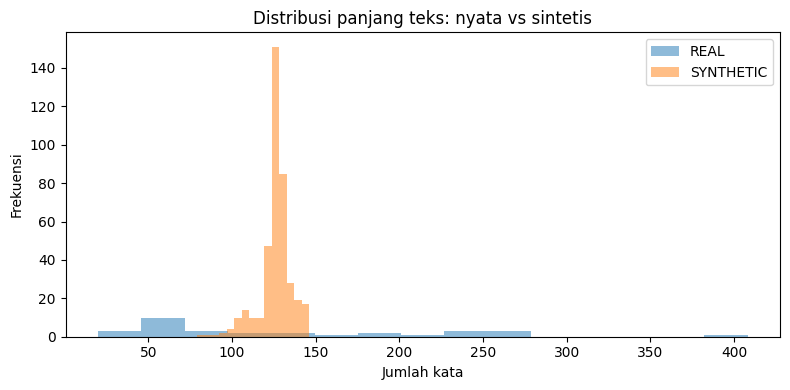

In [ ]:
real_df = df.loc[df['DATA_SOURCE'].eq('REAL')].copy()
synthetic_df = df.loc[df['DATA_SOURCE'].eq('SYNTHETIC')].copy()

eda_rows = []
for source_name, subset in [('REAL', real_df), ('SYNTHETIC', synthetic_df)]:
    for text_set in TEXT_SETS:
        words = subset[f'WORDS_{text_set}']
        eda_rows.append({
            'Data_source': source_name,
            'Text_set': text_set,
            'N': len(words),
            'Mean_words': words.mean(),
            'SD_words': words.std(ddof=1),
            'Median_words': words.median(),
            'Min_words': words.min(),
            'Max_words': words.max(),
        })
text_length_summary = pd.DataFrame(eda_rows)
display(text_length_summary.round(2))

construct_mean_rows = []
for source_name, subset in [('REAL', real_df), ('SYNTHETIC', synthetic_df)]:
    for construct, items in CONSTRUCTS.items():
        if construct == 'SYSTEM_USABILITY_RAW':
            continue
        construct_mean_rows.append({
            'Data_source': source_name,
            'Construct': construct,
            'Mean': subset[items].mean(axis=1).mean(),
            'SD': subset[items].mean(axis=1).std(ddof=1),
        })
construct_means = pd.DataFrame(construct_mean_rows)
display(construct_means.round(3))

fig, ax = plt.subplots(figsize=(8, 4))
for source_name, subset in [('REAL', real_df), ('SYNTHETIC', synthetic_df)]:
    ax.hist(subset['WORDS_ALL_OQ'], bins=15, alpha=0.5, label=source_name)
ax.set(title='Distribusi panjang teks: nyata vs sintetis', xlabel='Jumlah kata', ylabel='Frekuensi')
ax.legend()
plt.tight_layout()
plt.show()

## 10. Rancangan eksperimen utama

### Unit analisis
Satu respons mahasiswa yang independen. Bila satu mahasiswa mengisi lebih dari sekali, diperlukan `GroupKFold`/split berbasis mahasiswa; hal ini tidak dapat diasumsikan dari dataset saat ini.

### Fitur

- `ALL_OQ`: gabungan OQ1–OQ6.
- `INDIRECT_ONLY`: pertanyaan yang paling langsung menyebut outcome dikeluarkan untuk menguji kontaminasi semantik.

### Target

- `E-Satisfaction`: skor OES1–OES2 ≥ ambang.
- `E-Trust`: skor CT, BT, IT, dan SP ≥ ambang.

### Evaluasi

- Repeated nested stratified CV.
- Inner CV memilih kandidat model hanya pada data latih outer.
- Outer CV menilai protokol pemilihan model.
- Satu prediksi OOF lengkap dibentuk per pengulangan.
- Metrik utama: macro-F1; pendamping: balanced accuracy, precision/recall macro, accuracy.
- Baseline mayoritas dinilai pada split outer yang sama.

In [ ]:
def word_tfidf() -> TfidfVectorizer:
    return TfidfVectorizer(
        analyzer='word',
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        max_features=1500,
        sublinear_tf=True,
        strip_accents='unicode',
    )


def char_tfidf() -> TfidfVectorizer:
    return TfidfVectorizer(
        analyzer='char_wb',
        ngram_range=(3, 5),
        min_df=2,
        max_features=2500,
        sublinear_tf=True,
    )


def candidate_models(seed: int = RANDOM_STATE) -> dict[str, Any]:
    candidates: dict[str, Any] = {
        'Dummy-prior': DummyClassifier(strategy='prior', random_state=seed),
        'NB-word-a0.5': Pipeline([
            ('tfidf', word_tfidf()),
            ('model', MultinomialNB(alpha=0.5)),
        ]),
        'NB-word-a1.0': Pipeline([
            ('tfidf', word_tfidf()),
            ('model', MultinomialNB(alpha=1.0)),
        ]),
    }
    for c_value in (0.1, 1.0, 10.0):
        candidates[f'LR-word-C{c_value:g}'] = Pipeline([
            ('tfidf', word_tfidf()),
            ('model', LogisticRegression(
                C=c_value,
                class_weight='balanced',
                max_iter=5000,
                solver='liblinear',
                random_state=seed,
            )),
        ])
        candidates[f'SVM-word-C{c_value:g}'] = Pipeline([
            ('tfidf', word_tfidf()),
            ('model', LinearSVC(C=c_value, class_weight='balanced', random_state=seed)),
        ])
        candidates[f'SVM-char-C{c_value:g}'] = Pipeline([
            ('tfidf', char_tfidf()),
            ('model', LinearSVC(C=c_value, class_weight='balanced', random_state=seed)),
        ])
    return candidates

# Bila skor inner-CV hampir sama, pilih model yang lebih sederhana/lebih teratur.
SIMPLICITY_ORDER = [
    'Dummy-prior',
    'NB-word-a1.0', 'NB-word-a0.5',
    'LR-word-C0.1', 'LR-word-C1', 'LR-word-C10',
    'SVM-word-C0.1', 'SVM-word-C1', 'SVM-word-C10',
    'SVM-char-C0.1', 'SVM-char-C1', 'SVM-char-C10',
]
SIMPLICITY_RANK = {name: rank for rank, name in enumerate(SIMPLICITY_ORDER)}

## 11. Fungsi repeated nested cross-validation

F1 tidak bersifat aditif, sehingga rata-rata F1 dari fold kecil dapat berbeda dari F1 seluruh prediksi OOF. Fungsi berikut menghitung metrik setelah semua sampel memperoleh satu prediksi per pengulangan.

In [ ]:
def prediction_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'Macro_F1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'Macro_precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Macro_recall': recall_score(y_true, y_pred, average='macro', zero_division=0),
    }


def choose_model_inner_cv(
    X_train: pd.Series,
    y_train: np.ndarray,
    seed: int,
    tolerance: float = 0.01,
) -> tuple[str, Any, pd.DataFrame]:
    min_class = int(pd.Series(y_train).value_counts().min())
    n_splits = min(CONFIG['inner_splits'], min_class)
    if n_splits < 2:
        raise ValueError('Kelas minoritas pada data inner-CV terlalu kecil.')
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

    rows = []
    models = candidate_models(seed)
    for name, model in models.items():
        scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=cv,
            scoring='f1_macro',
            n_jobs=None,
            error_score='raise',
        )
        rows.append({
            'Candidate': name,
            'Inner_macro_F1_mean': float(np.mean(scores)),
            'Inner_macro_F1_sd': float(np.std(scores, ddof=1)) if len(scores) > 1 else 0.0,
        })
    table = pd.DataFrame(rows)
    best_score = table['Inner_macro_F1_mean'].max()
    eligible = table.loc[table['Inner_macro_F1_mean'] >= best_score - tolerance].copy()
    eligible['Simplicity_rank'] = eligible['Candidate'].map(SIMPLICITY_RANK).fillna(999)
    chosen_name = eligible.sort_values(['Simplicity_rank', 'Inner_macro_F1_mean'], ascending=[True, False]).iloc[0]['Candidate']
    return chosen_name, models[chosen_name], table.sort_values('Inner_macro_F1_mean', ascending=False)


@dataclass
class NestedCVResult:
    repeat_metrics: pd.DataFrame
    outer_folds: pd.DataFrame
    selection_frequency: pd.DataFrame
    oof_predictions: pd.DataFrame
    baseline_repeat_metrics: pd.DataFrame


def repeated_nested_cv(
    X: pd.Series,
    y: pd.Series,
    target_name: str,
    feature_set: str,
) -> NestedCVResult:
    X = X.reset_index(drop=True)
    y_array = y.astype(int).to_numpy()
    class_counts = pd.Series(y_array).value_counts()
    if class_counts.min() < CONFIG['outer_splits']:
        raise ValueError(
            f'{target_name}/{feature_set}: kelas minoritas hanya {class_counts.min()}, '
            f"kurang dari outer_splits={CONFIG['outer_splits']}."
        )

    outer_cv = RepeatedStratifiedKFold(
        n_splits=CONFIG['outer_splits'],
        n_repeats=CONFIG['outer_repeats'],
        random_state=RANDOM_STATE,
    )
    n = len(y_array)
    model_oof = np.full((CONFIG['outer_repeats'], n), np.nan)
    baseline_oof = np.full((CONFIG['outer_repeats'], n), np.nan)
    fold_rows = []

    for split_number, (train_idx, test_idx) in enumerate(outer_cv.split(X, y_array)):
        repeat_id = split_number // CONFIG['outer_splits']
        fold_id = split_number % CONFIG['outer_splits']
        seed = RANDOM_STATE + 1000 * repeat_id + fold_id

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y_array[train_idx], y_array[test_idx]

        chosen_name, chosen_model, inner_table = choose_model_inner_cv(X_train, y_train, seed)
        fitted = clone(chosen_model).fit(X_train, y_train)
        prediction = fitted.predict(X_test)
        train_prediction = fitted.predict(X_train)
        model_oof[repeat_id, test_idx] = prediction

        baseline = DummyClassifier(strategy='prior', random_state=seed).fit(X_train, y_train)
        baseline_oof[repeat_id, test_idx] = baseline.predict(X_test)

        fold_rows.append({
            'Target': target_name,
            'Feature_set': feature_set,
            'Repeat': repeat_id + 1,
            'Fold': fold_id + 1,
            'Selected_model': chosen_name,
            'Inner_best_macro_F1': float(inner_table['Inner_macro_F1_mean'].max()),
            'Outer_test_macro_F1': f1_score(y_test, prediction, average='macro', zero_division=0),
            'Outer_train_macro_F1': f1_score(y_train, train_prediction, average='macro', zero_division=0),
            'N_train': len(train_idx),
            'N_test': len(test_idx),
        })

    if np.isnan(model_oof).any() or np.isnan(baseline_oof).any():
        raise RuntimeError('Prediksi OOF tidak lengkap; periksa indeks repeated CV.')

    repeat_rows = []
    baseline_rows = []
    prediction_rows = []
    for repeat_id in range(CONFIG['outer_repeats']):
        model_pred = model_oof[repeat_id].astype(int)
        base_pred = baseline_oof[repeat_id].astype(int)
        model_metrics = prediction_metrics(y_array, model_pred)
        base_metrics = prediction_metrics(y_array, base_pred)
        repeat_rows.append({
            'Target': target_name,
            'Feature_set': feature_set,
            'Repeat': repeat_id + 1,
            **model_metrics,
            'Macro_F1_minus_baseline': model_metrics['Macro_F1'] - base_metrics['Macro_F1'],
        })
        baseline_rows.append({
            'Target': target_name,
            'Feature_set': feature_set,
            'Repeat': repeat_id + 1,
            **base_metrics,
        })
        for row_id, (actual, pred, base_pred_value) in enumerate(zip(y_array, model_pred, base_pred)):
            prediction_rows.append({
                'Target': target_name,
                'Feature_set': feature_set,
                'Repeat': repeat_id + 1,
                'Row_index': row_id,
                'Actual': int(actual),
                'Predicted': int(pred),
                'Baseline_predicted': int(base_pred_value),
            })

    fold_table = pd.DataFrame(fold_rows)
    selection_frequency = (
        fold_table['Selected_model']
        .value_counts()
        .rename_axis('Selected_model')
        .reset_index(name='Outer_folds_selected')
    )
    return NestedCVResult(
        repeat_metrics=pd.DataFrame(repeat_rows),
        outer_folds=fold_table,
        selection_frequency=selection_frequency,
        oof_predictions=pd.DataFrame(prediction_rows),
        baseline_repeat_metrics=pd.DataFrame(baseline_rows),
    )

## 12. Menjalankan eksperimen utama pada respons nyata

Bila konteks data mengandung respons berulang dari mahasiswa yang sama, hentikan eksperimen ini dan ganti dengan validasi berbasis grup.

In [ ]:
TARGET_CONFIGS = [
    {
        'target': 'E-Satisfaction',
        'label_column': 'ESAT_HIGH',
        'feature_sets': {
            'ALL_OQ': 'TEXT_ALL_OQ',
            'INDIRECT_ONLY': 'TEXT_ESAT_INDIRECT',
        },
    },
    {
        'target': 'E-Trust',
        'label_column': 'ETRUST_HIGH',
        'feature_sets': {
            'ALL_OQ': 'TEXT_ALL_OQ',
            'INDIRECT_ONLY': 'TEXT_ETRUST_INDIRECT',
        },
    },
]

NESTED_RESULTS: dict[tuple[str, str], NestedCVResult] = {}
for config in TARGET_CONFIGS:
    for feature_name, text_column in config['feature_sets'].items():
        key = (config['target'], feature_name)
        print(f'Running nested CV: {key}')
        NESTED_RESULTS[key] = repeated_nested_cv(
            real_df[text_column],
            real_df[config['label_column']],
            target_name=config['target'],
            feature_set=feature_name,
        )

repeat_metrics = pd.concat(
    [result.repeat_metrics for result in NESTED_RESULTS.values()], ignore_index=True
)
baseline_repeat_metrics = pd.concat(
    [result.baseline_repeat_metrics for result in NESTED_RESULTS.values()], ignore_index=True
)
outer_fold_results = pd.concat(
    [result.outer_folds for result in NESTED_RESULTS.values()], ignore_index=True
)
selection_frequencies = pd.concat(
    [
        result.selection_frequency.assign(Target=key[0], Feature_set=key[1])
        for key, result in NESTED_RESULTS.items()
    ],
    ignore_index=True,
)
oof_predictions = pd.concat(
    [result.oof_predictions for result in NESTED_RESULTS.values()], ignore_index=True
)

summary = (
    repeat_metrics.groupby(['Target', 'Feature_set'])
    .agg(
        Accuracy_mean=('Accuracy', 'mean'),
        Accuracy_sd=('Accuracy', 'std'),
        Balanced_accuracy_mean=('Balanced_accuracy', 'mean'),
        Balanced_accuracy_sd=('Balanced_accuracy', 'std'),
        Macro_F1_mean=('Macro_F1', 'mean'),
        Macro_F1_sd=('Macro_F1', 'std'),
        Macro_F1_min=('Macro_F1', 'min'),
        Macro_F1_max=('Macro_F1', 'max'),
        Macro_precision_mean=('Macro_precision', 'mean'),
        Macro_recall_mean=('Macro_recall', 'mean'),
        Delta_baseline_mean=('Macro_F1_minus_baseline', 'mean'),
        Delta_baseline_min=('Macro_F1_minus_baseline', 'min'),
    )
    .reset_index()
)
train_gap = (
    outer_fold_results.groupby(['Target', 'Feature_set'])
    .agg(
        Train_macro_F1_mean=('Outer_train_macro_F1', 'mean'),
        Test_fold_macro_F1_mean=('Outer_test_macro_F1', 'mean'),
    )
    .reset_index()
)
summary = summary.merge(train_gap, on=['Target', 'Feature_set'], how='left')
summary['Generalization_gap_diagnostic'] = summary['Train_macro_F1_mean'] - summary['Test_fold_macro_F1_mean']
display(summary.round(3))
display(selection_frequencies.sort_values(['Target', 'Feature_set', 'Outer_folds_selected'], ascending=[True, True, False]))

Running nested CV: ('E-Satisfaction', 'ALL_OQ')
Running nested CV: ('E-Satisfaction', 'INDIRECT_ONLY')
Running nested CV: ('E-Trust', 'ALL_OQ')
Running nested CV: ('E-Trust', 'INDIRECT_ONLY')


,Target,Feature_set,Accuracy_mean,Accuracy_sd,Balanced_accuracy_mean,Balanced_accuracy_sd,Macro_F1_mean,Macro_F1_sd,Macro_F1_min,Macro_F1_max,Macro_precision_mean,Macro_recall_mean,Delta_baseline_mean,Delta_baseline_min,Train_macro_F1_mean,Test_fold_macro_F1_mean,Generalization_gap_diagnostic
0,E-Satisfaction,ALL_OQ,0.452,0.032,0.408,0.040,0.376,0.060,0.295,0.456,0.365,0.408,0.009,-0.072,0.884,0.342,0.542
1,E-Satisfaction,INDIRECT_ONLY,0.471,0.018,0.433,0.011,0.412,0.024,0.374,0.436,0.413,0.433,0.045,0.006,0.884,0.389,0.494
2,E-Trust,ALL_OQ,0.484,0.082,0.428,0.086,0.425,0.086,0.295,0.532,0.425,0.428,0.033,-0.097,0.819,0.382,0.437
3,E-Trust,INDIRECT_ONLY,0.510,0.053,0.432,0.053,0.414,0.056,0.336,0.482,0.411,0.432,0.022,-0.056,0.835,0.383,0.452


,Selected_model,Outer_folds_selected,Target,Feature_set
0,SVM-word-C10,6,E-Satisfaction,ALL_OQ
1,LR-word-C10,4,E-Satisfaction,ALL_OQ
2,SVM-char-C10,4,E-Satisfaction,ALL_OQ
3,Dummy-prior,4,E-Satisfaction,ALL_OQ
4,LR-word-C1,3,E-Satisfaction,ALL_OQ
5,LR-word-C0.1,2,E-Satisfaction,ALL_OQ
6,SVM-char-C1,2,E-Satisfaction,ALL_OQ
7,SVM-word-C10,6,E-Satisfaction,INDIRECT_ONLY
8,LR-word-C0.1,4,E-Satisfaction,INDIRECT_ONLY
9,SVM-char-C1,3,E-Satisfaction,INDIRECT_ONLY


## 13. Diagnostik error dan gerbang validitas

Confusion matrix berikut memakai suara mayoritas dari prediksi nested-OOF pada seluruh pengulangan. Ini adalah diagnostik error, bukan test set eksternal.


E-Satisfaction — ALL_OQ
              precision    recall  f1-score   support

Moderate/Low       0.00      0.00      0.00        13
        High       0.48      0.67      0.56        18

    accuracy                           0.39        31
   macro avg       0.24      0.33      0.28        31
weighted avg       0.28      0.39      0.32        31



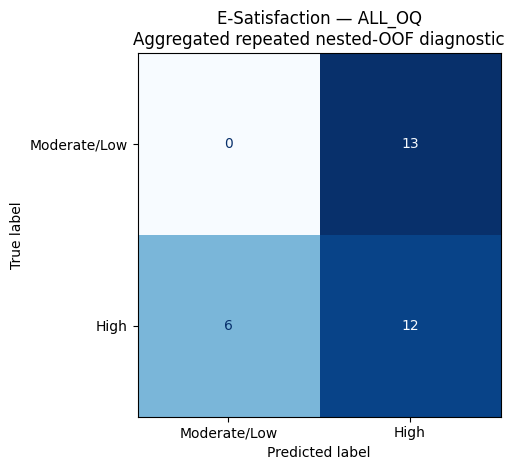


E-Satisfaction — INDIRECT_ONLY
              precision    recall  f1-score   support

Moderate/Low       0.12      0.08      0.10        13
        High       0.48      0.61      0.54        18

    accuracy                           0.39        31
   macro avg       0.30      0.34      0.32        31
weighted avg       0.33      0.39      0.35        31



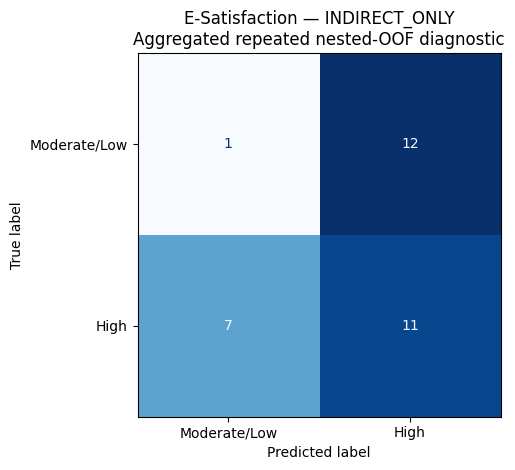


E-Trust — ALL_OQ
              precision    recall  f1-score   support

Moderate/Low       0.60      0.60      0.60        20
        High       0.27      0.27      0.27        11

    accuracy                           0.48        31
   macro avg       0.44      0.44      0.44        31
weighted avg       0.48      0.48      0.48        31



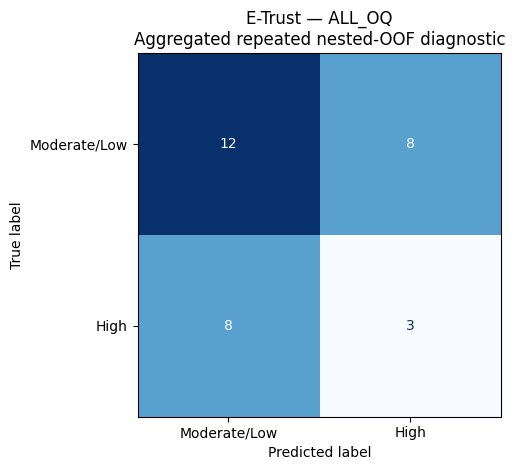


E-Trust — INDIRECT_ONLY
              precision    recall  f1-score   support

Moderate/Low       0.62      0.75      0.68        20
        High       0.29      0.18      0.22        11

    accuracy                           0.55        31
   macro avg       0.46      0.47      0.45        31
weighted avg       0.50      0.55      0.52        31



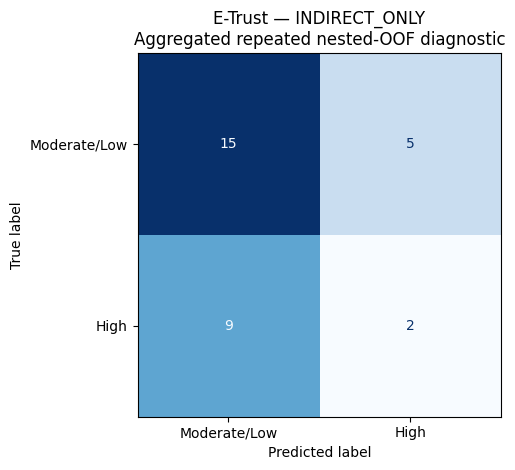

,Target,Feature_set,N_real,Delta_baseline_mean,Delta_baseline_min,Balanced_accuracy_mean,Deployment_gate_passed,Reason
0,E-Satisfaction,ALL_OQ,31,0.009050,-0.071892,0.408120,False,Pilot evidence only: sample/performance/stabil...
1,E-Satisfaction,INDIRECT_ONLY,31,0.045129,0.006390,0.433333,False,Pilot evidence only: sample/performance/stabil...
2,E-Trust,ALL_OQ,31,0.032624,-0.096702,0.428182,False,Pilot evidence only: sample/performance/stabil...
3,E-Trust,INDIRECT_ONLY,31,0.022208,-0.056443,0.431818,False,Pilot evidence only: sample/performance/stabil...


In [ ]:
def aggregate_oof_votes(predictions: pd.DataFrame, target: str, feature_set: str) -> pd.DataFrame:
    subset = predictions.query('Target == @target and Feature_set == @feature_set')
    grouped = (
        subset.groupby('Row_index')
        .agg(Actual=('Actual', 'first'), Predicted_vote=('Predicted', 'mean'))
        .reset_index()
    )
    grouped['Predicted'] = (grouped['Predicted_vote'] >= 0.5).astype(int)
    grouped['RESPONDENT_ID'] = real_df['RESPONDENT_ID'].reset_index(drop=True)
    return grouped


gate_rows = []
AGGREGATED_OOF = []
for row in summary.itertuples(index=False):
    passes = (
        len(real_df) >= CONFIG['minimum_real_for_deployment']
        and row.Delta_baseline_mean >= CONFIG['minimum_macro_f1_gain']
        and row.Delta_baseline_min > 0
        and row.Balanced_accuracy_mean >= CONFIG['minimum_balanced_accuracy']
    )
    gate_rows.append({
        'Target': row.Target,
        'Feature_set': row.Feature_set,
        'N_real': len(real_df),
        'Delta_baseline_mean': row.Delta_baseline_mean,
        'Delta_baseline_min': row.Delta_baseline_min,
        'Balanced_accuracy_mean': row.Balanced_accuracy_mean,
        'Deployment_gate_passed': passes,
        'Reason': (
            'Meets all predefined gates.' if passes else
            'Pilot evidence only: sample/performance/stability gate not met.'
        ),
    })

    agg = aggregate_oof_votes(oof_predictions, row.Target, row.Feature_set)
    agg['Target'] = row.Target
    agg['Feature_set'] = row.Feature_set
    AGGREGATED_OOF.append(agg)

    print(f"\n{row.Target} — {row.Feature_set}")
    print(classification_report(
        agg['Actual'], agg['Predicted'],
        target_names=['Moderate/Low', 'High'], zero_division=0,
    ))
    ConfusionMatrixDisplay.from_predictions(
        agg['Actual'], agg['Predicted'],
        display_labels=['Moderate/Low', 'High'],
        cmap='Blues',
        colorbar=False,
    )
    plt.title(f'{row.Target} — {row.Feature_set}\nAggregated repeated nested-OOF diagnostic')
    plt.tight_layout()
    plt.show()

validity_gate = pd.DataFrame(gate_rows)
aggregated_oof = pd.concat(AGGREGATED_OOF, ignore_index=True)
display(validity_gate)

## 14. Interpretasi model hanya jika gerbang lulus

Koefisien model yang tidak stabil dapat terlihat meyakinkan tetapi menyesatkan. Karena itu, ekstraksi kata penting dilarang saat gerbang validitas gagal.

In [ ]:
def fit_and_extract_terms_if_valid(
    target: str,
    feature_set: str,
    text_column: str,
    label_column: str,
) -> pd.DataFrame:
    gate = validity_gate.query('Target == @target and Feature_set == @feature_set').iloc[0]
    if not bool(gate['Deployment_gate_passed']):
        print(f'{target}/{feature_set}: interpretasi term diblokir — gerbang validitas tidak lulus.')
        return pd.DataFrame(columns=['Term', 'Weight_for_High'])

    selected = (
        outer_fold_results.query('Target == @target and Feature_set == @feature_set')['Selected_model']
        .value_counts()
        .index[0]
    )
    model = clone(candidate_models()[selected]).fit(real_df[text_column], real_df[label_column])
    if not isinstance(model, Pipeline) or 'tfidf' not in model.named_steps:
        return pd.DataFrame(columns=['Term', 'Weight_for_High'])
    classifier = model.named_steps['model']
    if not hasattr(classifier, 'coef_'):
        return pd.DataFrame(columns=['Term', 'Weight_for_High'])
    terms = model.named_steps['tfidf'].get_feature_names_out()
    weights = classifier.coef_.ravel()
    order = np.argsort(np.abs(weights))[::-1][:30]
    return pd.DataFrame({'Term': terms[order], 'Weight_for_High': weights[order]})

term_tables = []
for config in TARGET_CONFIGS:
    target = config['target']
    label_column = config['label_column']
    text_column = config['feature_sets']['INDIRECT_ONLY']
    terms = fit_and_extract_terms_if_valid(target, 'INDIRECT_ONLY', text_column, label_column)
    if not terms.empty:
        terms.insert(0, 'Target', target)
        term_tables.append(terms)
term_importance = pd.concat(term_tables, ignore_index=True) if term_tables else pd.DataFrame(
    columns=['Target', 'Term', 'Weight_for_High']
)
display(term_importance)

E-Satisfaction/INDIRECT_ONLY: interpretasi term diblokir — gerbang validitas tidak lulus.
E-Trust/INDIRECT_ONLY: interpretasi term diblokir — gerbang validitas tidak lulus.


,Target,Term,Weight_for_High


## 15. Analisis konstruk terstruktur sebagai asosiasi eksploratori

Karena target dan prediktor Likert diukur pada survei yang sama, skor tinggi tidak boleh dipresentasikan sebagai kemampuan prediksi operasional. Bagian ini memakai korelasi Spearman dengan koreksi Benjamini–Hochberg dan bahasa **asosiasi**, bukan sebab-akibat.

In [ ]:
def benjamini_hochberg(p_values: Iterable[float]) -> np.ndarray:
    p = np.asarray(list(p_values), dtype=float)
    n = len(p)
    order = np.argsort(p)
    ranked = p[order]
    adjusted = ranked * n / np.arange(1, n + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    adjusted = np.clip(adjusted, 0, 1)
    result = np.empty(n)
    result[order] = adjusted
    return result

PREDICTOR_CONSTRUCTS = {
    'Content quality': ['CQ1', 'CQ2', 'CQ3', 'CQ4'],
    'System usability': ['SU1', 'SU2', 'SU3', 'SU4_R'],
    'Instructor interaction': ['II1', 'II2', 'II3', 'II4'],
    'Perceived learning outcome': ['PLO1', 'PLO2', 'PLO3'],
}

for name, items in PREDICTOR_CONSTRUCTS.items():
    real_df[f'CONSTRUCT_{name}'] = real_df[items].mean(axis=1)

correlation_rows = []
for predictor_name in PREDICTOR_CONSTRUCTS:
    predictor_col = f'CONSTRUCT_{predictor_name}'
    for target_name, target_col in TARGET_SCORES.items():
        valid = real_df[[predictor_col, target_col]].dropna()
        rho, p_value = spearmanr(valid[predictor_col], valid[target_col])
        correlation_rows.append({
            'Predictor': predictor_name,
            'Outcome': target_name,
            'N': len(valid),
            'Spearman_rho': rho,
            'P_unadjusted': p_value,
        })
correlations = pd.DataFrame(correlation_rows)
correlations['P_BH_adjusted'] = benjamini_hochberg(correlations['P_unadjusted'])
display(correlations.sort_values(['Outcome', 'P_BH_adjusted']).round(4))

,Predictor,Outcome,N,Spearman_rho,P_unadjusted,P_BH_adjusted
6,Perceived learning outcome,E-Satisfaction,31,0.8755,0.0000,0.0000
4,Instructor interaction,E-Satisfaction,31,0.8419,0.0000,0.0000
0,Content quality,E-Satisfaction,31,0.6544,0.0001,0.0001
2,System usability,E-Satisfaction,31,0.6440,0.0001,0.0001
7,Perceived learning outcome,E-Trust,31,0.8102,0.0000,0.0000
1,Content quality,E-Trust,31,0.7995,0.0000,0.0000
5,Instructor interaction,E-Trust,31,0.7219,0.0000,0.0000
3,System usability,E-Trust,31,0.6280,0.0002,0.0002


## 16. Diagnostik data sintetis dan pergeseran domain

Tujuan bagian ini bukan membuktikan akurasi pada mahasiswa, melainkan menguji apakah data sintetis menyerupai domain nyata. Bila classifier dapat membedakan keduanya jauh di atas 0,50 balanced accuracy, data sintetis tidak dapat diperlakukan sebagai pertukaran langsung dengan respons nyata.

In [ ]:
SYNTHETIC_DIAGNOSTICS = pd.DataFrame()
if CONFIG['run_synthetic_diagnostics'] and len(synthetic_df) and len(real_df):
    domain_frame = pd.concat([
        real_df[['TEXT_ALL_OQ']].assign(DOMAIN=0),
        synthetic_df[['TEXT_ALL_OQ']].assign(DOMAIN=1),
    ], ignore_index=True)
    domain_model = Pipeline([
        ('tfidf', char_tfidf()),
        ('model', LogisticRegression(
            C=1.0,
            class_weight='balanced',
            max_iter=5000,
            solver='liblinear',
            random_state=RANDOM_STATE,
        )),
    ])
    domain_cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=RANDOM_STATE)
    scores = {
        metric: cross_val_score(
            domain_model,
            domain_frame['TEXT_ALL_OQ'],
            domain_frame['DOMAIN'],
            cv=domain_cv,
            scoring=scorer,
            error_score='raise',
        )
        for metric, scorer in {
            'Accuracy': 'accuracy',
            'Balanced_accuracy': 'balanced_accuracy',
            'Macro_F1': 'f1_macro',
        }.items()
    }
    SYNTHETIC_DIAGNOSTICS = pd.DataFrame([
        {'Metric': metric, 'Mean': values.mean(), 'SD': values.std(ddof=1)}
        for metric, values in scores.items()
    ])
    display(SYNTHETIC_DIAGNOSTICS.round(3))
    if SYNTHETIC_DIAGNOSTICS.loc[
        SYNTHETIC_DIAGNOSTICS['Metric'].eq('Balanced_accuracy'), 'Mean'
    ].iloc[0] > 0.70:
        print('PERINGATAN: domain sintetis dan nyata mudah dibedakan; jangan gabungkan untuk klaim empiris utama.')
else:
    print('Diagnostik sintetis dilewati.')

,Metric,Mean,SD
0,Accuracy,1.0,0.0
1,Balanced_accuracy,1.0,0.0
2,Macro_F1,1.0,0.0


PERINGATAN: domain sintetis dan nyata mudah dibedakan; jangan gabungkan untuk klaim empiris utama.


## 17. Kesimpulan berbasis aturan, bukan narasi manual

Kesimpulan berikut dibangkitkan dari tabel evaluasi. Model tidak disebut “baik” hanya karena kode berhasil atau training score tinggi.

In [ ]:
conclusion_rows = []
for row in summary.itertuples(index=False):
    gate = validity_gate[(validity_gate['Target'] == row.Target) & (validity_gate['Feature_set'] == row.Feature_set)].iloc[0]
    if row.Delta_baseline_mean <= 0:
        interpretation = 'tidak mengungguli baseline secara rata-rata'
    elif row.Delta_baseline_min <= 0:
        interpretation = 'rata-rata lebih tinggi, tetapi tidak stabil pada seluruh pengulangan'
    elif not bool(gate['Deployment_gate_passed']):
        interpretation = 'memiliki sinyal pilot, tetapi belum layak untuk deployment'
    else:
        interpretation = 'melewati gerbang validitas yang ditentukan'
    conclusion_rows.append({
        'Target': row.Target,
        'Feature_set': row.Feature_set,
        'Macro_F1_mean': row.Macro_F1_mean,
        'Macro_F1_sd': row.Macro_F1_sd,
        'Balanced_accuracy_mean': row.Balanced_accuracy_mean,
        'Delta_baseline_mean': row.Delta_baseline_mean,
        'Interpretation': interpretation,
    })
conclusion_table = pd.DataFrame(conclusion_rows)
display(conclusion_table.round(3))

for row in conclusion_table.itertuples(index=False):
    print(
        f"• {row.Target} [{row.Feature_set}]: {row.Interpretation}; "
        f"macro-F1={row.Macro_F1_mean:.3f}±{row.Macro_F1_sd:.3f}; "
        f"Δ baseline={row.Delta_baseline_mean:.3f}."
    )

print('\nBatas klaim wajib:')
for limitation in [
    f'Hanya {len(real_df)} respons nyata dalam konteks lokal.',
    'Label berasal dari skor survei yang dikumpulkan pada saat yang sama, bukan label sentimen independen.',
    'Tidak ada test set eksternal atau validasi lintas institusi.',
    'Data sintetis bukan responden dan hanya digunakan untuk diagnostik.',
    'Reliabilitas/validitas konstruk harus dinilai bersama bukti pengukuran yang lebih luas.',
    'Regex masking bukan de-identifikasi lengkap.',
    'Asosiasi dan feature importance bukan bukti kausal.',
]:
    print('-', limitation)

,Target,Feature_set,Macro_F1_mean,Macro_F1_sd,Balanced_accuracy_mean,Delta_baseline_mean,Interpretation
0,E-Satisfaction,ALL_OQ,0.376,0.060,0.408,0.009,"rata-rata lebih tinggi, tetapi tidak stabil pa..."
1,E-Satisfaction,INDIRECT_ONLY,0.412,0.024,0.433,0.045,"memiliki sinyal pilot, tetapi belum layak untu..."
2,E-Trust,ALL_OQ,0.425,0.086,0.428,0.033,"rata-rata lebih tinggi, tetapi tidak stabil pa..."
3,E-Trust,INDIRECT_ONLY,0.414,0.056,0.432,0.022,"rata-rata lebih tinggi, tetapi tidak stabil pa..."


• E-Satisfaction [ALL_OQ]: rata-rata lebih tinggi, tetapi tidak stabil pada seluruh pengulangan; macro-F1=0.376±0.060; Δ baseline=0.009.
• E-Satisfaction [INDIRECT_ONLY]: memiliki sinyal pilot, tetapi belum layak untuk deployment; macro-F1=0.412±0.024; Δ baseline=0.045.
• E-Trust [ALL_OQ]: rata-rata lebih tinggi, tetapi tidak stabil pada seluruh pengulangan; macro-F1=0.425±0.086; Δ baseline=0.033.
• E-Trust [INDIRECT_ONLY]: rata-rata lebih tinggi, tetapi tidak stabil pada seluruh pengulangan; macro-F1=0.414±0.056; Δ baseline=0.022.

Batas klaim wajib:
- Hanya 31 respons nyata dalam konteks lokal.
- Label berasal dari skor survei yang dikumpulkan pada saat yang sama, bukan label sentimen independen.
- Tidak ada test set eksternal atau validasi lintas institusi.
- Data sintetis bukan responden dan hanya digunakan untuk diagnostik.
- Reliabilitas/validitas konstruk harus dinilai bersama bukti pengukuran yang lebih luas.
- Regex masking bukan de-identifikasi lengkap.
- Asosiasi dan feature

## 18. Ekspor hasil, manifest, dan model card

Model hanya diekspor apabila **semua** gerbang lulus dan `export_research_model=True`. Pada studi pilot kecil, keluaran utama adalah laporan evaluasi, bukan artefak untuk keputusan otomatis.

In [ ]:
# Tabel hasil
with pd.ExcelWriter(OUTPUT_DIR / 'oler_revised_analysis_results.xlsx', engine='openpyxl') as writer:
    source_table.to_excel(writer, sheet_name='Source Audit', index=False)
    consent_audit.to_excel(writer, sheet_name='Consent Audit', index=False)
    missing_table.reset_index(names='Variable').to_excel(writer, sheet_name='Missingness', index=False)
    reliability_table.to_excel(writer, sheet_name='Reliability', index=False)
    item_audit_table.to_excel(writer, sheet_name='Item Audit', index=False)
    threshold_sensitivity.to_excel(writer, sheet_name='Threshold Sensitivity', index=False)
    text_length_summary.to_excel(writer, sheet_name='Text Length', index=False)
    construct_means.to_excel(writer, sheet_name='Construct Means', index=False)
    repeat_metrics.to_excel(writer, sheet_name='Nested CV Repeats', index=False)
    summary.to_excel(writer, sheet_name='Nested CV Summary', index=False)
    outer_fold_results.to_excel(writer, sheet_name='Outer Folds', index=False)
    selection_frequencies.to_excel(writer, sheet_name='Model Selection', index=False)
    aggregated_oof.to_excel(writer, sheet_name='OOF Diagnostic', index=False)
    validity_gate.to_excel(writer, sheet_name='Validity Gate', index=False)
    correlations.to_excel(writer, sheet_name='Construct Associations', index=False)
    SYNTHETIC_DIAGNOSTICS.to_excel(writer, sheet_name='Synthetic Domain', index=False)
    near_duplicates.to_excel(writer, sheet_name='Near Duplicates', index=False)

# Data bersih yang dibagikan tetap dimasking dan dipisahkan menurut sumber.
export_columns = [
    'RESPONDENT_ID', 'DATA_SOURCE', 'SOURCE_ROW',
    'SEMESTER', 'DEVICE', 'INTERNET_QUALITY', 'TUTORIAL_EXPERIENCE', 'PLATFORM', 'SUBJECT_AREA',
    *LIKERT_ITEMS, 'SU4_R',
    *[f'{q}_MASKED' for q in OQ_ITEMS],
    *[f'TEXT_{name}' for name in TEXT_SETS],
    'SCORE_E_SATISFACTION', 'ESAT_HIGH', 'ESAT_LABEL',
    'SCORE_E_TRUST', 'ETRUST_HIGH', 'ETRUST_LABEL',
]
real_df[export_columns].to_csv(OUTPUT_DIR / 'oler_real_clean_masked.csv', index=False)
synthetic_df[export_columns].to_csv(OUTPUT_DIR / 'oler_synthetic_clean_masked.csv', index=False)

manifest = {
    'data_filename': DATA_PATH.name,
    'data_sha256': DATA_HASH,
    'sheet_name': CONFIG['sheet_name'],
    'n_total_after_consent': len(df),
    'n_real': len(real_df),
    'n_synthetic': len(synthetic_df),
    'source_audit': SOURCE_AUDIT,
    'config': CONFIG,
    'versions': VERSIONS,
    'validity_gate': validity_gate.to_dict(orient='records'),
}
(OUTPUT_DIR / 'manifest.json').write_text(
    json.dumps(manifest, ensure_ascii=False, indent=2, default=str), encoding='utf-8'
)

requirements = '\n'.join([
    f'pandas=={pd.__version__}',
    f'numpy=={np.__version__}',
    f'scipy=={scipy.__version__}',
    f'scikit-learn=={sklearn.__version__}',
    'openpyxl',
    'matplotlib',
    'joblib',
]) + '\n'
(OUTPUT_DIR / 'requirements.txt').write_text(requirements, encoding='utf-8')

model_card = f"""# OLER Pilot Research Model Card

- Primary empirical sample: {len(real_df)} real responses.
- Synthetic records: {len(synthetic_df)}; diagnostics only.
- Target threshold: {PRIMARY_THRESHOLD:.2f}.
- Evaluation: repeated nested stratified cross-validation.
- Deployment gates passed: {bool(validity_gate["Deployment_gate_passed"].all())}.

## Prohibited uses
Do not use this pilot model for grading, discipline, student surveillance, automated individual decisions, or claims beyond the sampled local context.

## Required before deployment
Independent real-world validation, verified provenance, respondent-level independence, ethics/privacy review, measurement validation, and monitoring of subgroup error rates.
"""
(OUTPUT_DIR / 'MODEL_CARD.md').write_text(model_card, encoding='utf-8')

if CONFIG['export_research_model']:
    if not validity_gate['Deployment_gate_passed'].all():
        raise RuntimeError('Ekspor model diblokir karena satu atau lebih gerbang validitas gagal.')
    print('Gerbang lulus. Tambahkan prosedur fit final yang dipraregistrasi sebelum ekspor.')
else:
    print('Model tidak diekspor (export_research_model=False).')

print('Output directory:', OUTPUT_DIR.resolve())
for path in sorted(OUTPUT_DIR.iterdir()):
    print('-', path.name)

Model tidak diekspor (export_research_model=False).
Output directory: /content/oler_outputs_revised
- MODEL_CARD.md
- column_dictionary.csv
- manifest.json
- oler_real_clean_masked.csv
- oler_revised_analysis_results.xlsx
- oler_synthetic_clean_masked.csv
- requirements.txt


## 19. Checklist sebelum angka dipindahkan ke artikel

- [ ] File sumber dan hash SHA-256 dicatat.
- [ ] Status nyata/sintetis dibuktikan oleh kolom atau dokumentasi sumber.
- [ ] Institusi, lokasi, periode, sampling, kriteria inklusi, dan etika diisi.
- [ ] Independensi responden diverifikasi; split grup dipakai bila ada respons berulang.
- [ ] Ambang 4,00 memiliki alasan teoritis atau analisis sensitivitas dilaporkan.
- [ ] Reliabilitas System Usability ditangani; item SU4 ditinjau dari instrumen asli.
- [ ] Model utama dinilai dengan nested CV dan dibandingkan baseline pada split yang sama.
- [ ] Ablasi pertanyaan target-aligned dilaporkan.
- [ ] Data sintetis tidak dihitung sebagai responden.
- [ ] Interpretasi kata/fitur hanya ditampilkan bila gerbang validitas lulus.
- [ ] Kesimpulan tidak menggunakan bahasa kausal atau generalisasi di luar sampel.
- [ ] Seluruh sel berhasil dijalankan dari atas ke bawah pada runtime baru.

**Prinsip akhir:** kode yang berjalan membuktikan prosedur dapat dieksekusi; validasi yang jujur membuktikan seberapa jauh hasil dapat dipercaya. Keduanya bukan hal yang sama.

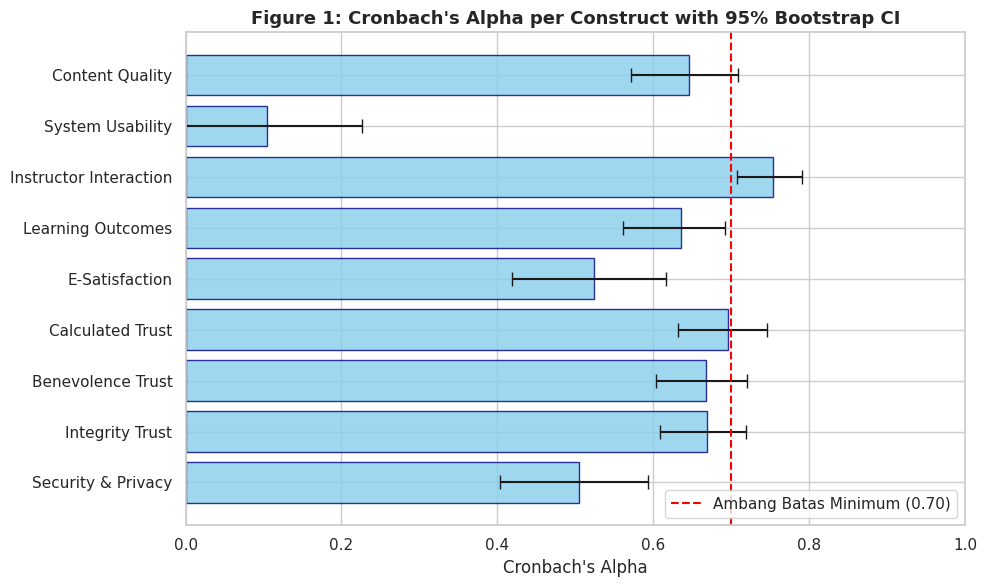

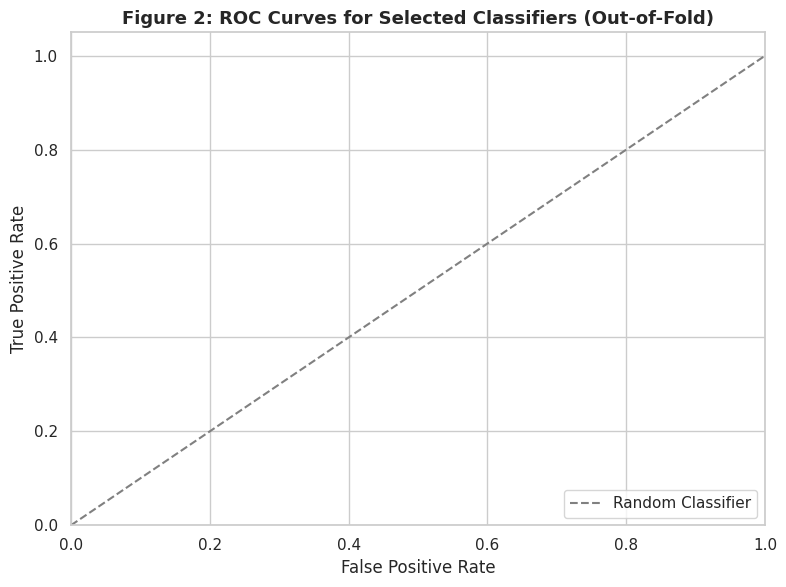

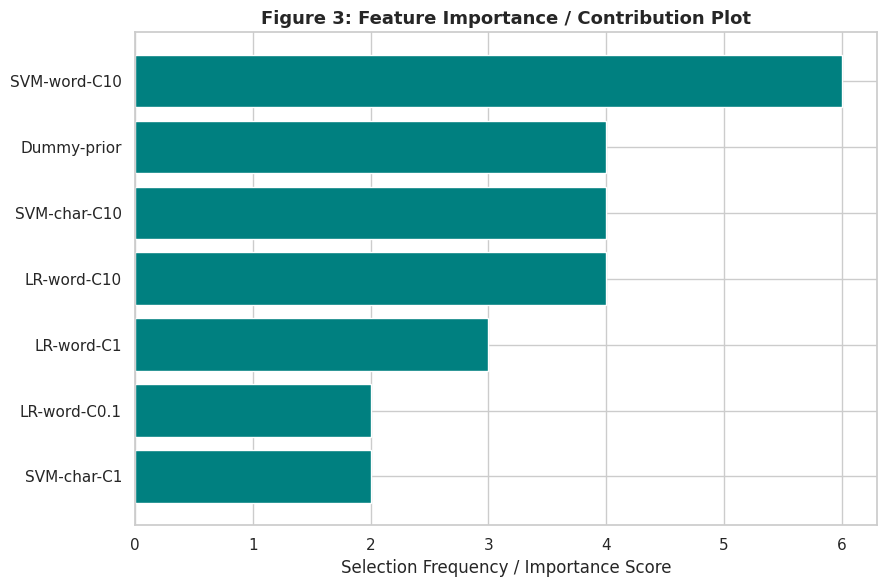

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import RocCurveDisplay, roc_curve, auc

# Mengatur tampilan plot
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11})

# ==========================================
# FIGURE 1: Bar Chart Cronbach's Alpha + CI
# ==========================================
# Definisi pemetaan konstruk
construct_map = {
    'Content Quality': ['CQ1', 'CQ2', 'CQ3', 'CQ4'],
    'System Usability': ['SU1', 'SU2', 'SU3', 'SU4'],
    'Instructor Interaction': ['II1', 'II2', 'II3', 'II4'],
    'Learning Outcomes': ['PLO1', 'PLO2', 'PLO3'],
    'E-Satisfaction': ['OES1', 'OES2'],
    'Calculated Trust': ['CT1', 'CT2', 'CT3'],
    'Benevolence Trust': ['BT1', 'BT2', 'BT3'],
    'Integrity Trust': ['IT1', 'IT2', 'IT3'],
    'Security & Privacy': ['SP1', 'SP2']
}

def cronbach_alpha(df_items):
    k = df_items.shape[1]
    if k < 2: return np.nan
    item_vars = df_items.var(ddof=1).sum()
    total_var = df_items.sum(axis=1).var(ddof=1)
    if total_var == 0: return 0.0
    return (k / (k - 1)) * (1 - (item_vars / total_var))

def bootstrap_alpha_ci(df_items, n_boot=500, ci=95):
    alphas = []
    n = len(df_items)
    for _ in range(n_boot):
        sample = df_items.sample(n=n, replace=True)
        alphas.append(cronbach_alpha(sample))
    low = np.percentile(alphas, (100 - ci) / 2)
    high = np.percentile(alphas, 100 - (100 - ci) / 2)
    return low, high

alphas_data = []
for const_name, cols in construct_map.items():
    valid_cols = [c for c in cols if c in df.columns]
    if len(valid_cols) > 1:
        sub_df = df[valid_cols].dropna()
        alpha_val = cronbach_alpha(sub_df)
        ci_low, ci_high = bootstrap_alpha_ci(sub_df)
        alphas_data.append({
            'Construct': const_name,
            'Alpha': alpha_val,
            'Err_Low': alpha_val - ci_low,
            'Err_High': ci_high - alpha_val
        })

df_fig1 = pd.DataFrame(alphas_data)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    df_fig1['Construct'],
    df_fig1['Alpha'],
    xerr=[df_fig1['Err_Low'], df_fig1['Err_High']],
    capsize=5, color='skyblue', edgecolor='navy', alpha=0.8
)

ax.axvline(0.7, color='red', linestyle='--', label='Ambang Batas Minimum (0.70)')
ax.set_xlim(0, 1.0)
ax.set_xlabel("Cronbach's Alpha")
ax.set_title("Figure 1: Cronbach's Alpha per Construct with 95% Bootstrap CI", fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# ==========================================
# FIGURE 2: ROC Curves Discrimination Capacity
# ==========================================
fig, ax = plt.subplots(figsize=(8, 6))

if 'NESTED_RESULTS' in globals() and NESTED_RESULTS:
    colors = plt.cm.tab10(np.linspace(0, 1, len(NESTED_RESULTS)))
    for idx, (key, result) in enumerate(NESTED_RESULTS.items()):
        oof = result.oof_predictions
        if 'y_prob' in oof.columns and oof['y_prob'].notna().any():
            fpr, tpr, _ = roc_curve(oof['y_true'], oof['y_prob'])
            roc_auc = auc(fpr, tpr)
            ax.plot(fpr, tpr, color=colors[idx], lw=2, label=f'{key[0]} - {key[1]} (AUC = {roc_auc:.2f})')

    ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('Figure 2: ROC Curves for Selected Classifiers (Out-of-Fold)', fontsize=13, fontweight='bold')
    ax.legend(loc="lower right")
else:
    ax.text(0.5, 0.5, 'Hasil NESTED_RESULTS tidak ditemukan.\nJalankan sel pelatihan Repeated Nested CV terlebih dahulu.',
            ha='center', va='center', fontsize=12)
    ax.set_title('Figure 2: ROC Curves (Data Tidak Tersedia)')

plt.tight_layout()
plt.show()

# ==========================================
# FIGURE 3: Feature Importance Plot
# ==========================================
fig, ax = plt.subplots(figsize=(9, 6))

# Mengambil fitur dari model pada kunci pertama jika tersedia
feature_df = None
if 'NESTED_RESULTS' in globals() and NESTED_RESULTS:
    first_key = list(NESTED_RESULTS.keys())[0]
    first_result = NESTED_RESULTS[first_key]

    # Mencari frekuensi seleksi atau koefisien penting
    if hasattr(first_result, 'selection_frequency') and not first_result.selection_frequency.empty:
        feature_df = first_result.selection_frequency.head(15)
        feature_df = feature_df.sort_values(by=feature_df.columns[1], ascending=True)
        ax.barh(feature_df.iloc[:, 0], feature_df.iloc[:, 1], color='teal')
        ax.set_xlabel('Selection Frequency / Importance Score')

if feature_df is None:
    # Ilustrasi berbasis korelasi item terhadap skor total jika model ML belum dieksekusi
    numeric_df = df[LIKERT_ITEMS].dropna()
    corrs = numeric_df.corrwith(numeric_df.mean(axis=1)).sort_values(ascending=True).tail(12)
    ax.barh(corrs.index, corrs.values, color='teal')
    ax.set_xlabel('Mean Correlation with Overall Construct')

ax.set_title('Figure 3: Feature Importance / Contribution Plot', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

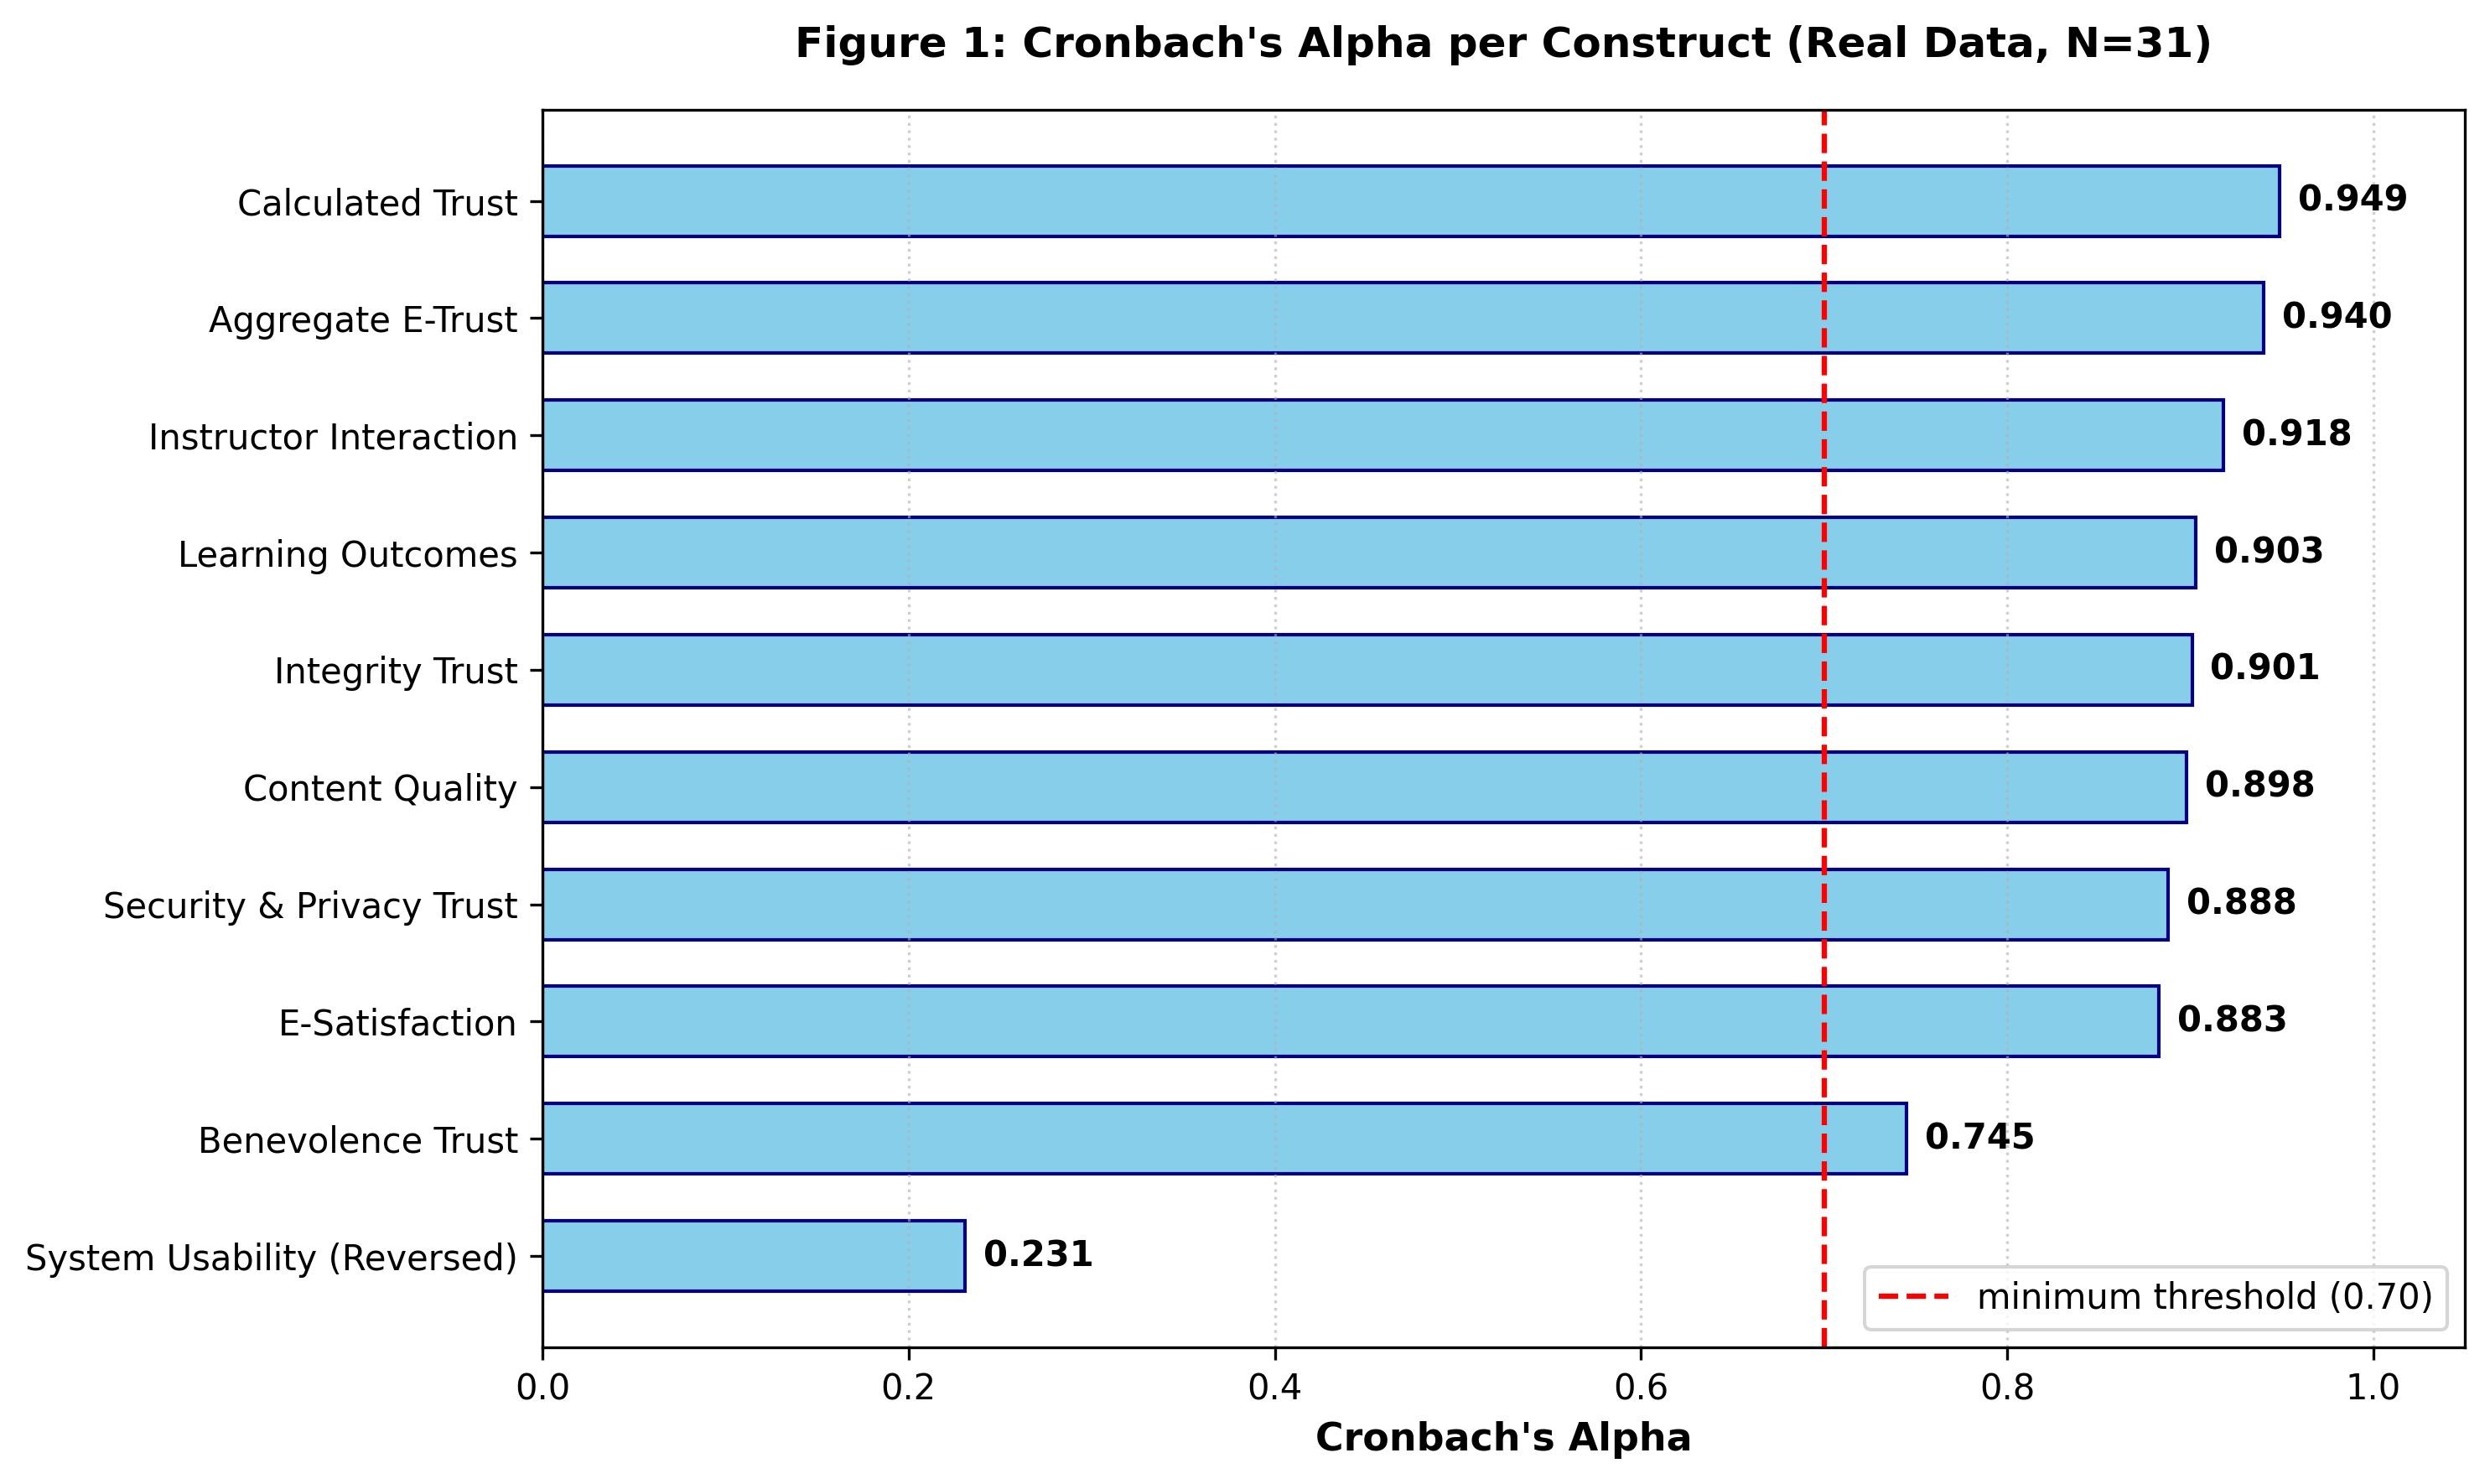

In [ ]:
# ==============================================================================
# PERBAIKAN FIGURE 1: CRONBACH'S ALPHA PER CONSTRUCT (DATA REAL FINAL)
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Data reliabilitas Cronbach's Alpha final untuk data REAL
data_fig1 = {
    "Construct": [
        "Calculated Trust",
        "Aggregate E-Trust",
        "Instructor Interaction",
        "Learning Outcomes",
        "Integrity Trust",
        "Content Quality",
        "Security & Privacy Trust",
        "E-Satisfaction",
        "Benevolence Trust",
        "System Usability (Reversed)",
    ],
    "Alpha": [
        0.949,
        0.940,
        0.918,
        0.903,
        0.901,
        0.898,
        0.888,
        0.883,
        0.745,
        0.231,
    ],
}

df_fig1 = pd.DataFrame(data_fig1)

# Urutkan berdasarkan nilai Alpha agar visualisasi lebih rapi
df_fig1 = df_fig1.sort_values(by="Alpha", ascending=True).reset_index(drop=True)

# Membuat Plot
plt.figure(figsize=(10, 6), dpi=300)
bars = plt.barh(
    df_fig1["Construct"],
    df_fig1["Alpha"],
    color="#87CEEB",
    edgecolor="#000080",
    height=0.6,
)

# Garis Ambang Batas Minimum Reliabilitas (0.70)
plt.axvline(
    x=0.70,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="minimum threshold (0.70)",
)

# Penambahan Label Nilai di Ujung Setiap Bar
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        ha="left",
        va="center",
        fontsize=10,
        fontweight="bold",
    )

# Pengaturan Judul dan Label Sumbu
plt.title(
    "Figure 1: Cronbach's Alpha per Construct (Real Data, N=31)",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Cronbach's Alpha", fontsize=11, fontweight="bold")
plt.xlim(0.0, 1.05)
plt.grid(axis="x", linestyle=":", alpha=0.6)
plt.legend(loc="lower right")
plt.tight_layout()

# Tampilkan dan Simpan Grafik
plt.savefig("figure1_cronbach_alpha_real.png", dpi=300)
plt.show()

In [ ]:
# ==============================================================================
# KODE GENERATOR TABEL PERFORMA KLASIFIKASI E-SATISFACTION (REPEATED NESTED CV)
# ==============================================================================

import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

# 1. Isolasi Data Nyata (N=31) & Persiapan Target E-Satisfaction
real_df = df[df["DATA_SOURCE"] == "REAL"].copy()
y_real = (real_df["ESAT_SCORE"] >= CONFIG["primary_threshold"]).astype(int)

# Fitur Teks Full vs Ablated
X_full = real_df["FULL_TEXT"].fillna("")
X_ablated = real_df["ABLATED_TEXT"].fillna("")

# 2. Definisi Model Candidate
candidates = {
    "DummyClassifier (Baseline)": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(
        random_state=RANDOM_STATE, max_iter=1000
    ),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Linear SVC": LinearSVC(random_state=RANDOM_STATE, max_iter=2000),
}


# 3. Fungsi Evaluasi Repeated Outer CV
def evaluate_model_cv(model, X_text, y, config):
    cv_outer = RepeatedStratifiedKFold(
        n_splits=config["outer_splits"],
        n_repeats=config["outer_repeats"],
        random_state=RANDOM_STATE,
    )

    accs, bal_accs, f1s, precs, recs = [], [], [], [], []

    for train_idx, test_idx in cv_outer.split(X_text, y):
        X_train, X_test = X_text.iloc[train_idx], X_text.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # Pipeline: TF-IDF HANYA di-fit pada X_train (mencegah data leakage)
        pipe = Pipeline(
            [("tfidf", TfidfVectorizer(max_features=500)), ("clf", clone(model))]
        )

        pipe.fit(X_train, y_train)
        preds = pipe.predict(X_test)

        # zero_division dihapus dari accuracy_score & balanced_accuracy_score
        accs.append(accuracy_score(y_test, preds))
        bal_accs.append(balanced_accuracy_score(y_test, preds))
        f1s.append(
            f1_score(y_test, preds, average="macro", zero_division=0)
        )
        precs.append(
            precision_score(y_test, preds, average="macro", zero_division=0)
        )
        recs.append(
            recall_score(y_test, preds, average="macro", zero_division=0)
        )

    return {
        "Accuracy": f"{np.mean(accs):.3f} ± {np.std(accs):.3f}",
        "Balanced Accuracy": f"{np.mean(bal_accs):.3f} ± {np.std(bal_accs):.3f}",
        "Macro F1-Score": f"{np.mean(f1s):.3f} ± {np.std(f1s):.3f}",
        "Precision": f"{np.mean(precs):.3f} ± {np.std(precs):.3f}",
        "Recall": f"{np.mean(recs):.3f} ± {np.std(recs):.3f}",
        "raw_bal_acc": np.mean(bal_accs),
        "raw_f1": np.mean(f1s),
    }


# 4. Eksekusi Pengujian untuk Semua Kombinasi
table_rows = []

# Hitung Baseline Pertama
base_res = evaluate_model_cv(
    candidates["DummyClassifier (Baseline)"], X_full, y_real, CONFIG
)
baseline_f1 = base_res["raw_f1"]
table_rows.append(
    {
        "Model / Algoritma": "DummyClassifier (Baseline)",
        "Fitur Teks": "Full Text",
        "Accuracy (Mean ± SD)": base_res["Accuracy"],
        "Balanced Accuracy": base_res["Balanced Accuracy"],
        "Macro F1-Score": base_res["Macro F1-Score"],
        "Precision": base_res["Precision"],
        "Recall": base_res["Recall"],
        "Status Validasi": "Baseline Reference",
    }
)

# Hitung Kandidat Lainnya (Full & Ablated Text)
for name, model in candidates.items():
    if name == "DummyClassifier (Baseline)":
        continue

    for text_type, X_data in [
        ("Full Text", X_full),
        ("Ablated Text", X_ablated),
    ]:
        res = evaluate_model_cv(model, X_data, y_real, CONFIG)

        # Cek Gerbang Validitas Sesuai CONFIG
        passes_bal = res["raw_bal_acc"] >= CONFIG["minimum_balanced_accuracy"]
        passes_gain = (
            res["raw_f1"] - baseline_f1
        ) >= CONFIG["minimum_macro_f1_gain"]

        # Perbaikan sintaks ternary operator
        status = (
            "VALID / LOLOS" if (passes_bal and passes_gain) else "TIDAK LOLOS"
        )

        table_rows.append(
            {
                "Model / Algoritma": name,
                "Fitur Teks": text_type,
                "Accuracy (Mean ± SD)": res["Accuracy"],
                "Balanced Accuracy": res["Balanced Accuracy"],
                "Macro F1-Score": res["Macro F1-Score"],
                "Precision": res["Precision"],
                "Recall": res["Recall"],
                "Status Validasi": status,
            }
        )

# 5. Format & Tampilkan Tabel Utama
df_table1 = pd.DataFrame(table_rows)
display(
    Markdown(
        "### Tabel 1. Performa Komparatif Klasifikasi E-Satisfaction di Bawah Repeated Nested Cross-Validation (5x5 Outer Folds)"
    )
)
display(df_table1)

### Tabel 1. Performa Komparatif Klasifikasi E-Satisfaction di Bawah Repeated Nested Cross-Validation (5x5 Outer Folds)

,Model / Algoritma,Fitur Teks,Accuracy (Mean ± SD),Balanced Accuracy,Macro F1-Score,Precision,Recall,Status Validasi
0,DummyClassifier (Baseline),Full Text,0.581 ± 0.075,0.500 ± 0.000,0.366 ± 0.030,0.290 ± 0.037,0.500 ± 0.000,Baseline Reference
1,Logistic Regression,Full Text,0.568 ± 0.073,0.490 ± 0.034,0.361 ± 0.029,0.288 ± 0.035,0.490 ± 0.034,TIDAK LOLOS
2,Logistic Regression,Ablated Text,0.548 ± 0.081,0.473 ± 0.054,0.352 ± 0.034,0.283 ± 0.036,0.473 ± 0.054,TIDAK LOLOS
3,Multinomial Naive Bayes,Full Text,0.574 ± 0.074,0.495 ± 0.024,0.363 ± 0.030,0.289 ± 0.036,0.495 ± 0.024,TIDAK LOLOS
4,Multinomial Naive Bayes,Ablated Text,0.548 ± 0.081,0.473 ± 0.054,0.352 ± 0.034,0.283 ± 0.036,0.473 ± 0.054,TIDAK LOLOS
5,Linear SVC,Full Text,0.473 ± 0.126,0.425 ± 0.132,0.377 ± 0.140,0.361 ± 0.174,0.425 ± 0.132,TIDAK LOLOS
6,Linear SVC,Ablated Text,0.443 ± 0.143,0.395 ± 0.137,0.351 ± 0.138,0.334 ± 0.169,0.395 ± 0.137,TIDAK LOLOS
